In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, warnings, json
from scipy.signal import savgol_filter
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, DDPG
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.noise import NormalActionNoise

warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

In [8]:
plt.rcParams.update({
    'font.family'    : 'DejaVu Sans',
    'font.size'      : 11,
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'figure.dpi'     : 130,
    'savefig.dpi'    : 180,
    'savefig.bbox'   : 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PAL = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f']
EXP_COLORS = {
    'ex_1':'#1f77b4','ex_9':'#ff7f0e','ex_20':'#2ca02c',
    'ex_21':'#d62728','ex_23':'#9467bd','ex_24':'#8c564b',
    'ex_4':'#e377c2','ex_22':'#7f7f7f'
}

print('All imports successful.')

All imports successful.


In [10]:
TRAIN_PATH = 'combined_train_data.csv'  
TEST_PATH  = 'combined_test_data.csv'   

df_train_raw = pd.read_csv(TRAIN_PATH)
df_test_raw  = pd.read_csv(TEST_PATH)

# Sort each experiment by time
df_train_raw = df_train_raw.sort_values(['experiment_id','time']).reset_index(drop=True)
df_test_raw  = df_test_raw.sort_values(['experiment_id','time']).reset_index(drop=True)

TRAIN_EXPS = sorted(df_train_raw['experiment_id'].unique())
TEST_EXPS  = sorted(df_test_raw['experiment_id'].unique())

print('═' * 55)
print(f'  TRAINING SET:  {len(df_train_raw):>7,} rows | {len(TRAIN_EXPS)} experiments')
print(f'  TEST SET:      {len(df_test_raw):>7,} rows | {len(TEST_EXPS)} experiments')
print('═' * 55)

print('\nTraining experiments:')
for eid, grp in df_train_raw.groupby('experiment_id'):
    dur = grp['time'].max() - grp['time'].min()
    print(f'  {eid}: {len(grp):>6,} rows | duration={dur:.0f}s | '
          f'V=[{grp["input_voltage"].min():.1f},{grp["input_voltage"].max():.1f}]V | '
          f'P=[{grp["el_power"].min():.0f},{grp["el_power"].max():.0f}]W')

print('\nTest experiments:')
for eid, grp in df_test_raw.groupby('experiment_id'):
    dur = grp['time'].max() - grp['time'].min()
    print(f'  {eid}: {len(grp):>6,} rows | duration={dur:.0f}s | '
          f'V=[{grp["input_voltage"].min():.1f},{grp["input_voltage"].max():.1f}]V | '
          f'P=[{grp["el_power"].min():.0f},{grp["el_power"].max():.0f}]W')

print('\nMissing values — Train:', df_train_raw.isnull().sum().to_dict())
print('Missing values — Test: ', df_test_raw.isnull().sum().to_dict())

═══════════════════════════════════════════════════════
  TRAINING SET:   52,940 rows | 6 experiments
  TEST SET:       18,285 rows | 2 experiments
═══════════════════════════════════════════════════════

Training experiments:
  ex_1:  9,920 rows | duration=9911s | V=[3.0,10.0]V | P=[933,3250]W
  ex_20:  6,495 rows | duration=6975s | V=[3.0,10.0]V | P=[1097,3182]W
  ex_21:  6,495 rows | duration=6929s | V=[3.0,10.0]V | P=[1046,3192]W
  ex_23:  9,188 rows | duration=10145s | V=[3.0,9.6]V | P=[1053,3194]W
  ex_24:  9,023 rows | duration=9769s | V=[3.0,10.0]V | P=[1054,3191]W
  ex_9: 11,819 rows | duration=11818s | V=[3.4,7.2]V | P=[1204,2512]W

Test experiments:
  ex_22:  8,490 rows | duration=9547s | V=[3.0,10.0]V | P=[1023,3185]W
  ex_4:  9,795 rows | duration=9787s | V=[3.0,10.0]V | P=[1110,3393]W

Missing values — Train: {'time': 0, 'input_voltage': 0, 'el_power': 0, 'experiment_id': 0}
Missing values — Test:  {'time': 0, 'input_voltage': 0, 'el_power': 0, 'experiment_id': 0}


In [12]:
print('TRAINING SET — Descriptive Statistics')
display(df_train_raw[['input_voltage','el_power']].describe().round(3))
print('\nTEST SET — Descriptive Statistics')
display(df_test_raw[['input_voltage','el_power']].describe().round(3))

TRAINING SET — Descriptive Statistics


,input_voltage,el_power
count,52940.000,52940.000
mean,5.506,1843.316
std,2.550,723.126
min,3.000,932.837
25%,3.000,1205.744
50%,4.842,1605.754
75%,7.421,2399.419
max,10.000,3249.891



TEST SET — Descriptive Statistics


,input_voltage,el_power
count,18285.000,18285.000
mean,5.836,1956.282
std,2.840,808.697
min,3.000,1022.500
25%,3.000,1215.567
50%,5.000,1626.421
75%,8.734,2729.477
max,10.000,3393.229


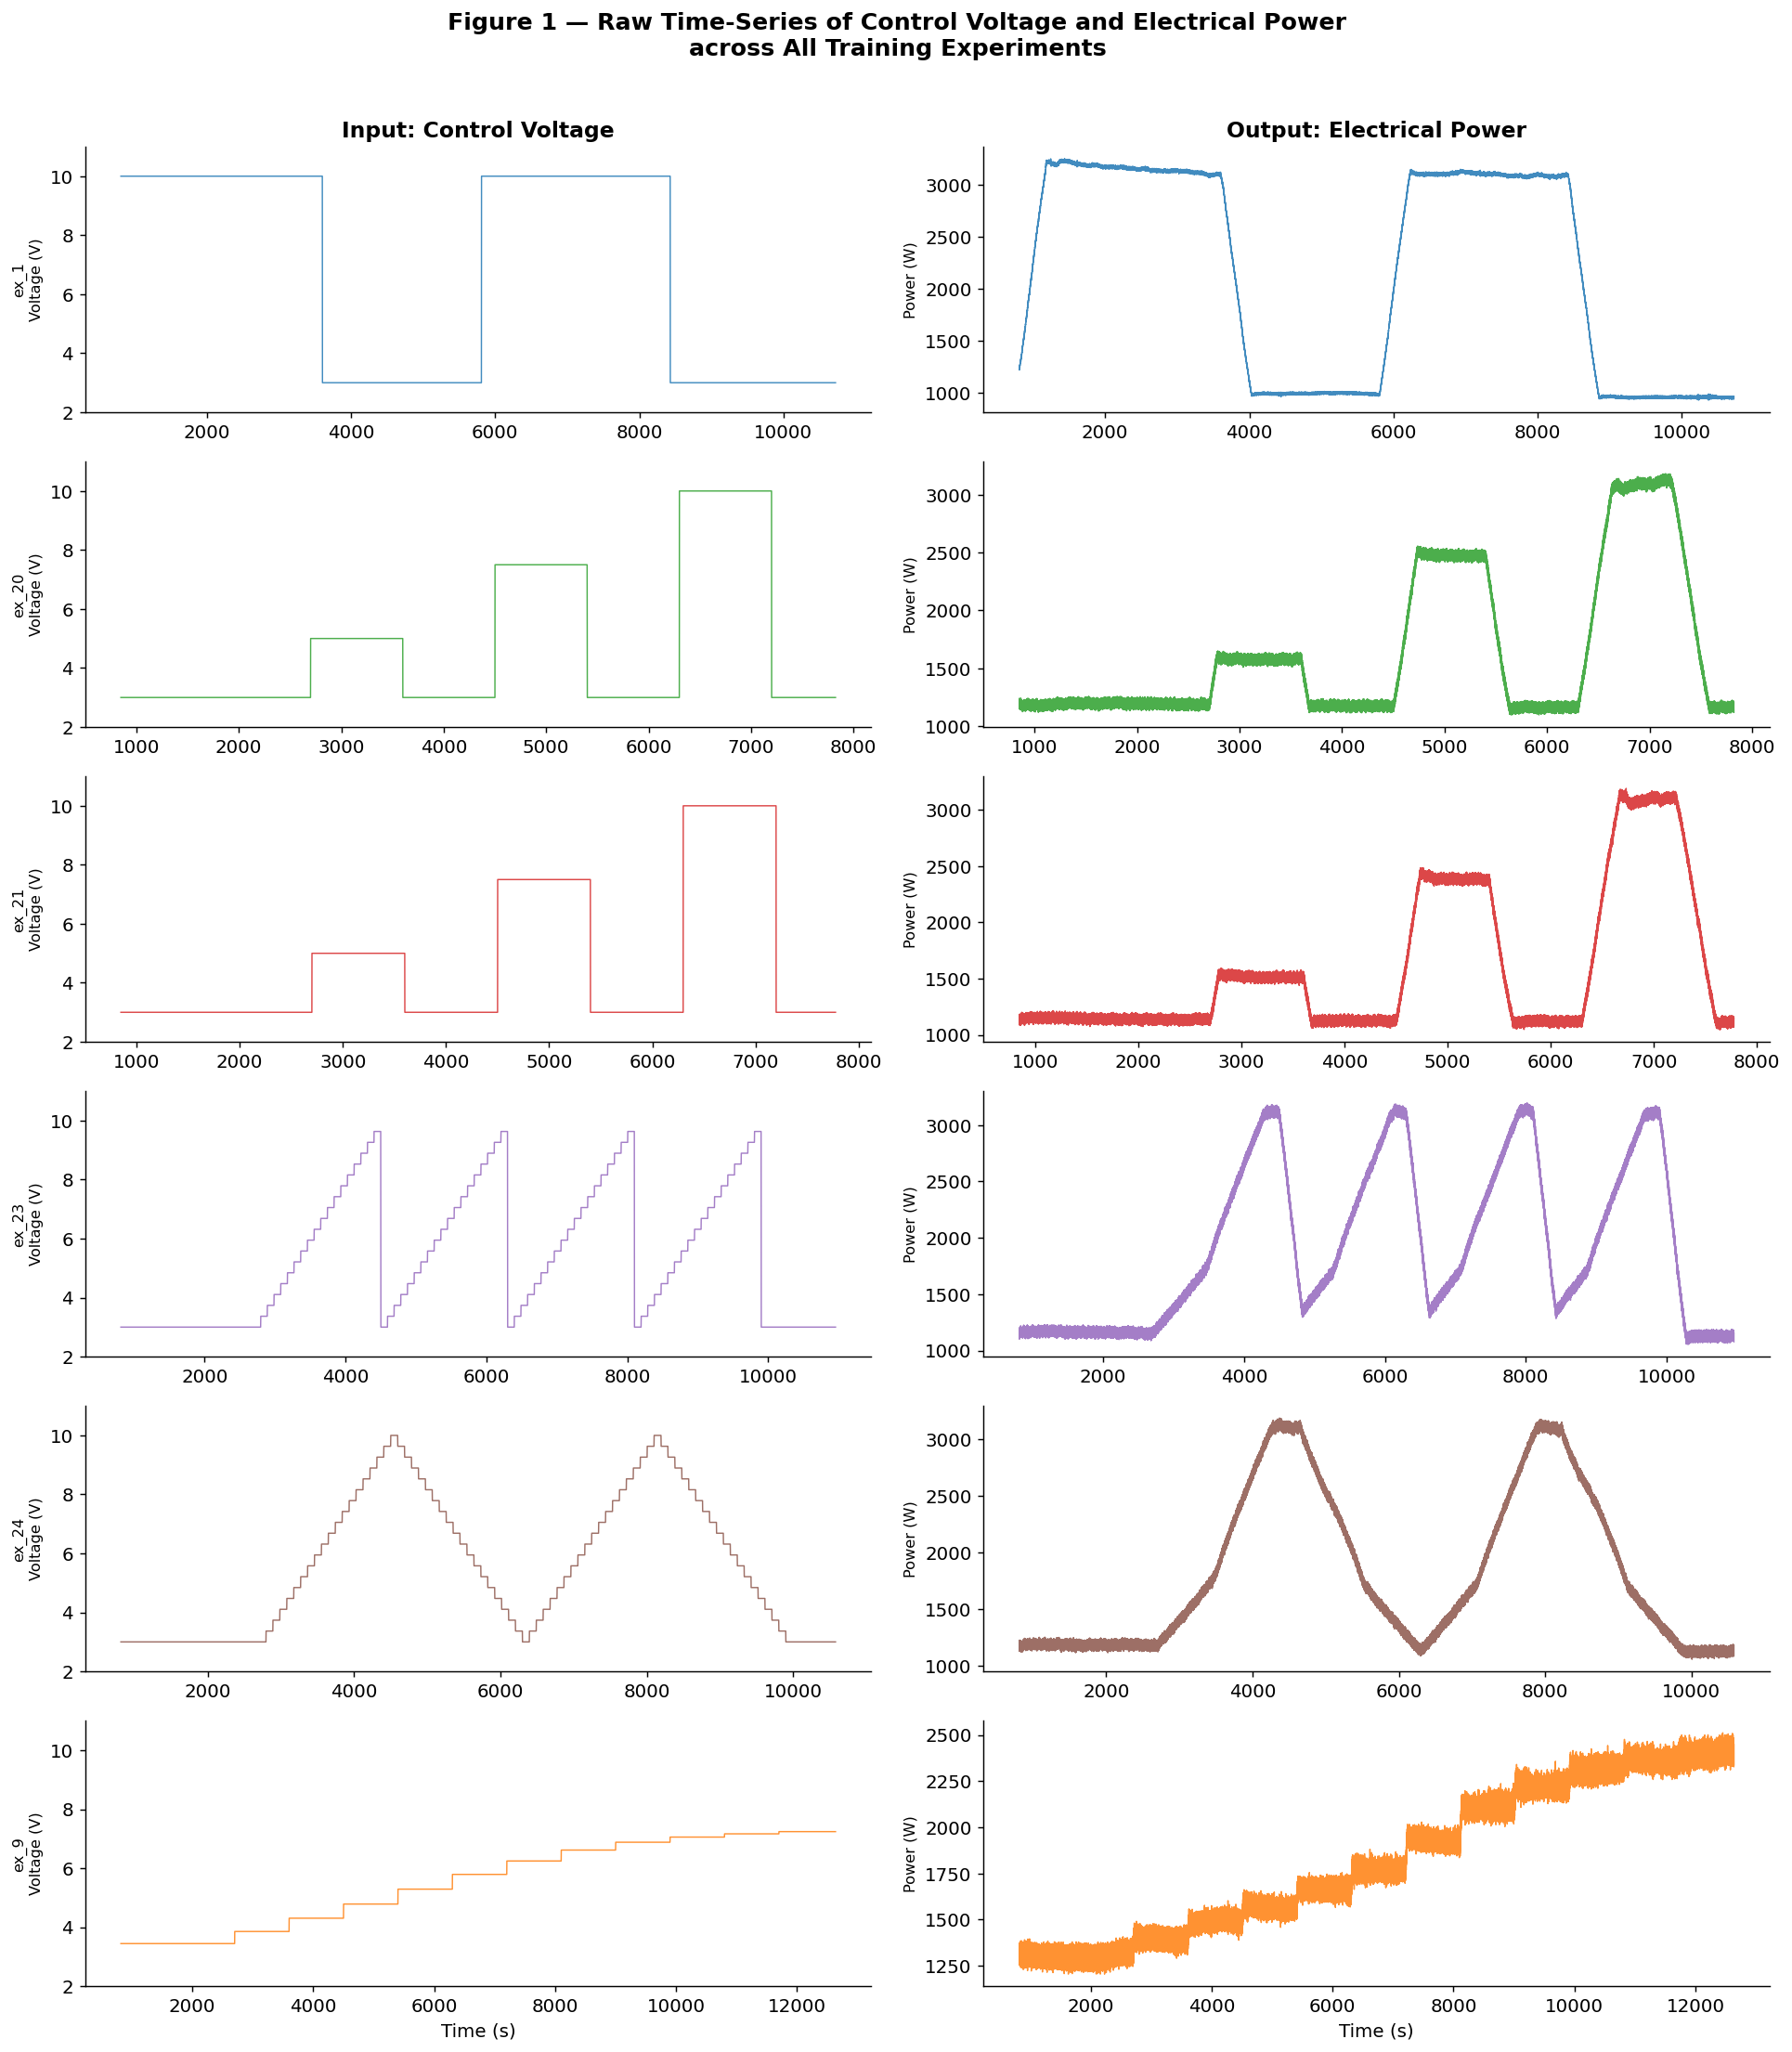

In [14]:
n_train = len(TRAIN_EXPS)
fig, axes = plt.subplots(n_train, 2, figsize=(15, 2.8 * n_train))
fig.suptitle('Figure 1 — Raw Time-Series of Control Voltage and Electrical Power\n'
             'across All Training Experiments', fontsize=14, fontweight='bold', y=1.01)

for row, eid in enumerate(TRAIN_EXPS):
    sub = df_train_raw[df_train_raw['experiment_id'] == eid]
    col = EXP_COLORS[eid]
    t   = sub['time'].values

    axes[row, 0].plot(t, sub['input_voltage'], color=col, lw=0.8, alpha=0.85)
    axes[row, 0].set_ylabel(f'{eid}\nVoltage (V)', fontsize=9)
    axes[row, 0].set_ylim(2, 11)
    if row == 0: axes[row, 0].set_title('Input: Control Voltage', fontweight='bold')
    if row == n_train - 1: axes[row, 0].set_xlabel('Time (s)')

    axes[row, 1].plot(t, sub['el_power'], color=col, lw=0.8, alpha=0.85)
    axes[row, 1].set_ylabel('Power (W)', fontsize=9)
    if row == 0: axes[row, 1].set_title('Output: Electrical Power', fontweight='bold')
    if row == n_train - 1: axes[row, 1].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('figures/fig01_raw_time_series.png')
plt.show()

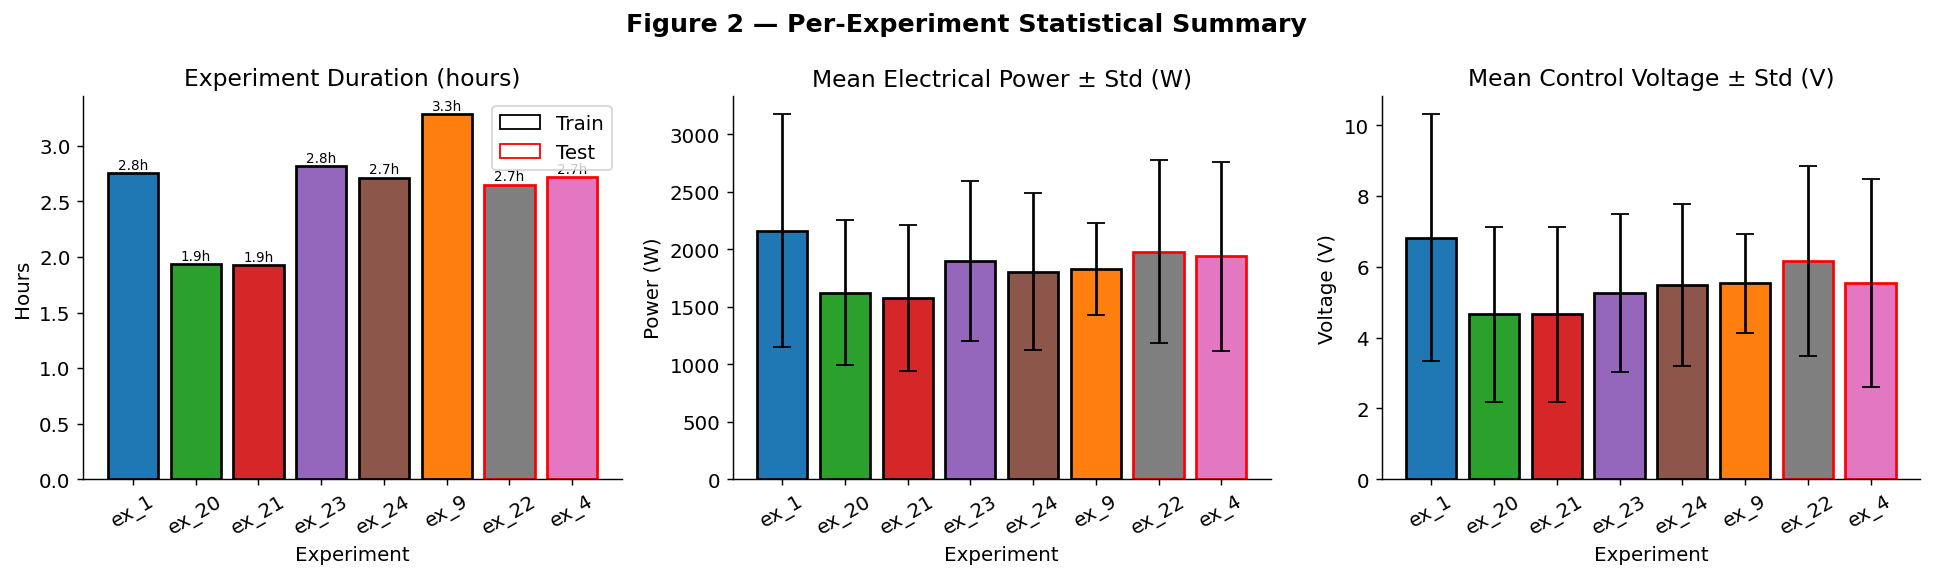

Statistical Summary Table:


,Experiment,Split,N,Duration_h,V_mean,V_std,P_mean,P_std,P_max
0,ex_1,Train,9920,2.75,6.82,3.49,2162.43,1009.47,3249.89
1,ex_20,Train,6495,1.94,4.66,2.48,1623.26,632.99,3182.43
2,ex_21,Train,6495,1.92,4.66,2.48,1576.46,638.04,3191.97
3,ex_23,Train,9188,2.82,5.26,2.24,1899.23,693.04,3193.85
4,ex_24,Train,9023,2.71,5.49,2.30,1805.38,680.14,3191.10
5,ex_9,Train,11819,3.28,5.54,1.40,1828.55,402.17,2511.70
6,ex_22,Test,8490,2.65,6.17,2.67,1976.71,795.04,3184.62
7,ex_4,Test,9795,2.72,5.55,2.95,1938.58,819.98,3393.23


In [16]:
all_exps  = TRAIN_EXPS + TEST_EXPS
all_data  = pd.concat([df_train_raw, df_test_raw], ignore_index=True)
stat_rows = []
for eid in all_exps:
    sub = all_data[all_data['experiment_id'] == eid]
    stat_rows.append({
        'Experiment': eid,
        'N': len(sub),
        'Duration_h': (sub['time'].max() - sub['time'].min()) / 3600,
        'V_mean': sub['input_voltage'].mean(),
        'V_std' : sub['input_voltage'].std(),
        'P_mean': sub['el_power'].mean(),
        'P_std' : sub['el_power'].std(),
        'P_max' : sub['el_power'].max(),
        'Split' : 'Train' if eid in TRAIN_EXPS else 'Test'
    })
stats_df = pd.DataFrame(stat_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Figure 2 — Per-Experiment Statistical Summary', fontsize=14, fontweight='bold')

bar_cols = [EXP_COLORS[e] for e in all_exps]
edge_cols = ['black' if s == 'Train' else 'red' for s in stats_df['Split']]

bars = axes[0].bar(stats_df['Experiment'], stats_df['Duration_h'],
                   color=bar_cols, edgecolor=edge_cols, linewidth=1.5)
axes[0].set_title('Experiment Duration (hours)')
axes[0].set_ylabel('Hours'); axes[0].set_xlabel('Experiment')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, stats_df['Duration_h']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.1f}h', ha='center', va='bottom', fontsize=7.5)

axes[1].bar(stats_df['Experiment'], stats_df['P_mean'],
            color=bar_cols, edgecolor=edge_cols, linewidth=1.5,
            yerr=stats_df['P_std'], capsize=5)
axes[1].set_title('Mean Electrical Power ± Std (W)')
axes[1].set_ylabel('Power (W)'); axes[1].set_xlabel('Experiment')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(stats_df['Experiment'], stats_df['V_mean'],
            color=bar_cols, edgecolor=edge_cols, linewidth=1.5,
            yerr=stats_df['V_std'], capsize=5)
axes[2].set_title('Mean Control Voltage ± Std (V)')
axes[2].set_ylabel('Voltage (V)'); axes[2].set_xlabel('Experiment')
axes[2].tick_params(axis='x', rotation=30)

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor='white',edgecolor='black',label='Train'),
                         Patch(facecolor='white',edgecolor='red',label='Test')], loc='upper right')

plt.tight_layout()
plt.savefig('figures/fig02_experiment_statistics.png')
plt.show()

print("Statistical Summary Table:")
display(stats_df[['Experiment','Split','N','Duration_h','V_mean','V_std','P_mean','P_std','P_max']].round(2))

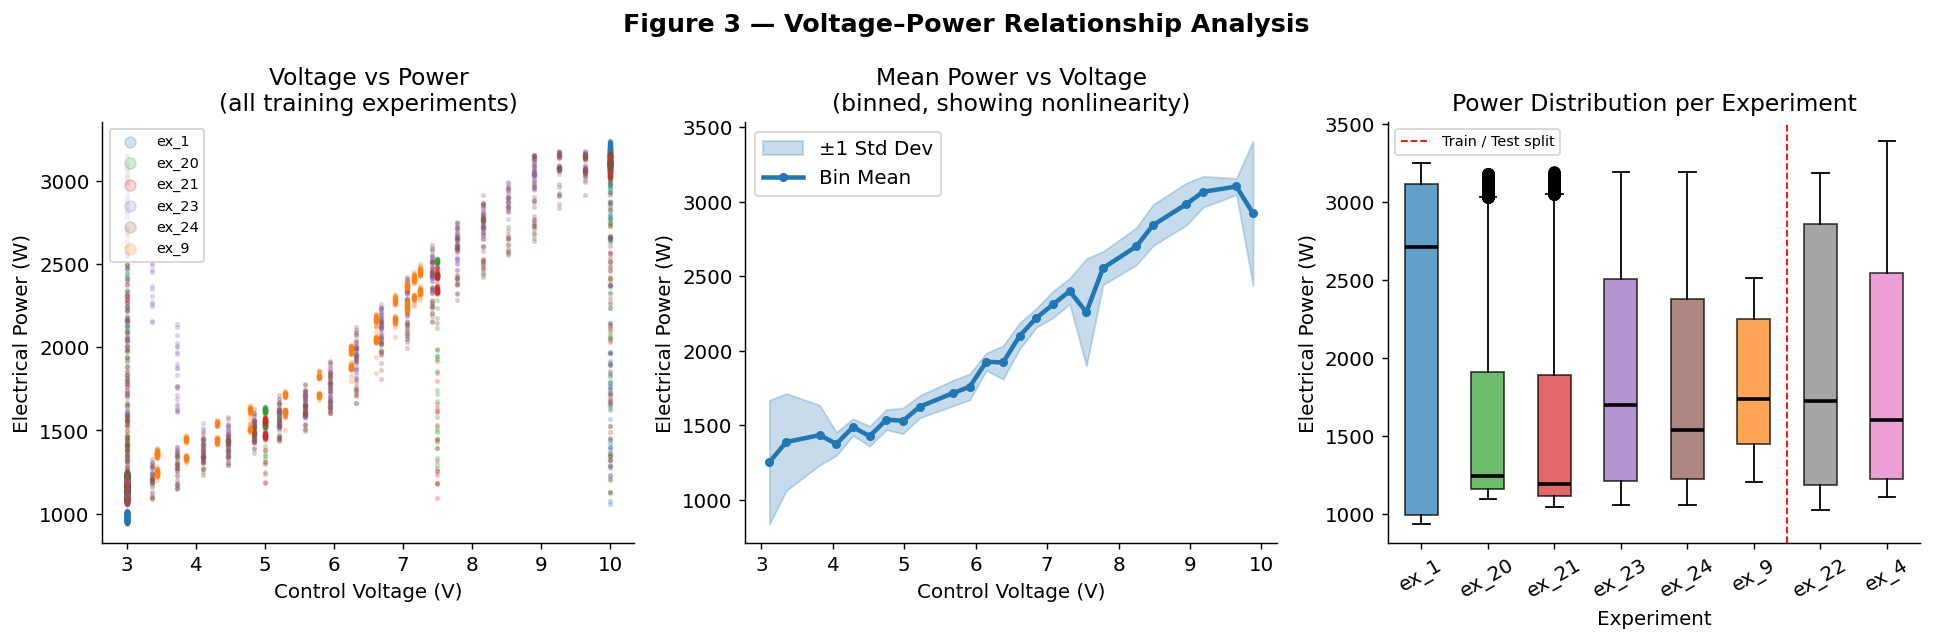

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 3 — Voltage–Power Relationship Analysis', fontsize=14, fontweight='bold')

# Scatter: all training data
for eid in TRAIN_EXPS:
    sub = df_train_raw[df_train_raw['experiment_id'] == eid].sample(min(800, len(df_train_raw[df_train_raw['experiment_id']==eid])), random_state=42)
    axes[0].scatter(sub['input_voltage'], sub['el_power'],
                    alpha=0.2, s=4, color=EXP_COLORS[eid], label=eid)
axes[0].set_title('Voltage vs Power\n(all training experiments)')
axes[0].set_xlabel('Control Voltage (V)')
axes[0].set_ylabel('Electrical Power (W)')
axes[0].legend(markerscale=3, fontsize=8, loc='upper left')

# Binned mean — shows the nonlinear V→P curve
df_train_raw['v_bin'] = pd.cut(df_train_raw['input_voltage'], bins=30)
binned = df_train_raw.groupby('v_bin', observed=True)['el_power'].agg(['mean','std']).dropna()
bin_centers = [interval.mid for interval in binned.index]
axes[1].fill_between(bin_centers,
                     binned['mean'] - binned['std'],
                     binned['mean'] + binned['std'],
                     alpha=0.25, color=PAL[0], label='±1 Std Dev')
axes[1].plot(bin_centers, binned['mean'], color=PAL[0], lw=2.5, marker='o',
             markersize=4, label='Bin Mean')
axes[1].set_title('Mean Power vs Voltage\n(binned, showing nonlinearity)')
axes[1].set_xlabel('Control Voltage (V)')
axes[1].set_ylabel('Electrical Power (W)')
axes[1].legend()
df_train_raw.drop(columns='v_bin', inplace=True)

# Power boxplots per experiment
all_data_plot = pd.concat([df_train_raw, df_test_raw])
exp_order = TRAIN_EXPS + TEST_EXPS
plot_data = [all_data_plot[all_data_plot['experiment_id']==e]['el_power'].values for e in exp_order]
bp = axes[2].boxplot(plot_data, labels=exp_order, patch_artist=True,
                     medianprops=dict(color='black', lw=2))
for patch, eid in zip(bp['boxes'], exp_order):
    patch.set_facecolor(EXP_COLORS[eid]); patch.set_alpha(0.7)
axes[2].set_title('Power Distribution per Experiment')
axes[2].set_xlabel('Experiment'); axes[2].set_ylabel('Electrical Power (W)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].axvline(6.5, color='red', linestyle='--', lw=1, label='Train / Test split')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig03_voltage_power_analysis.png')
plt.show()

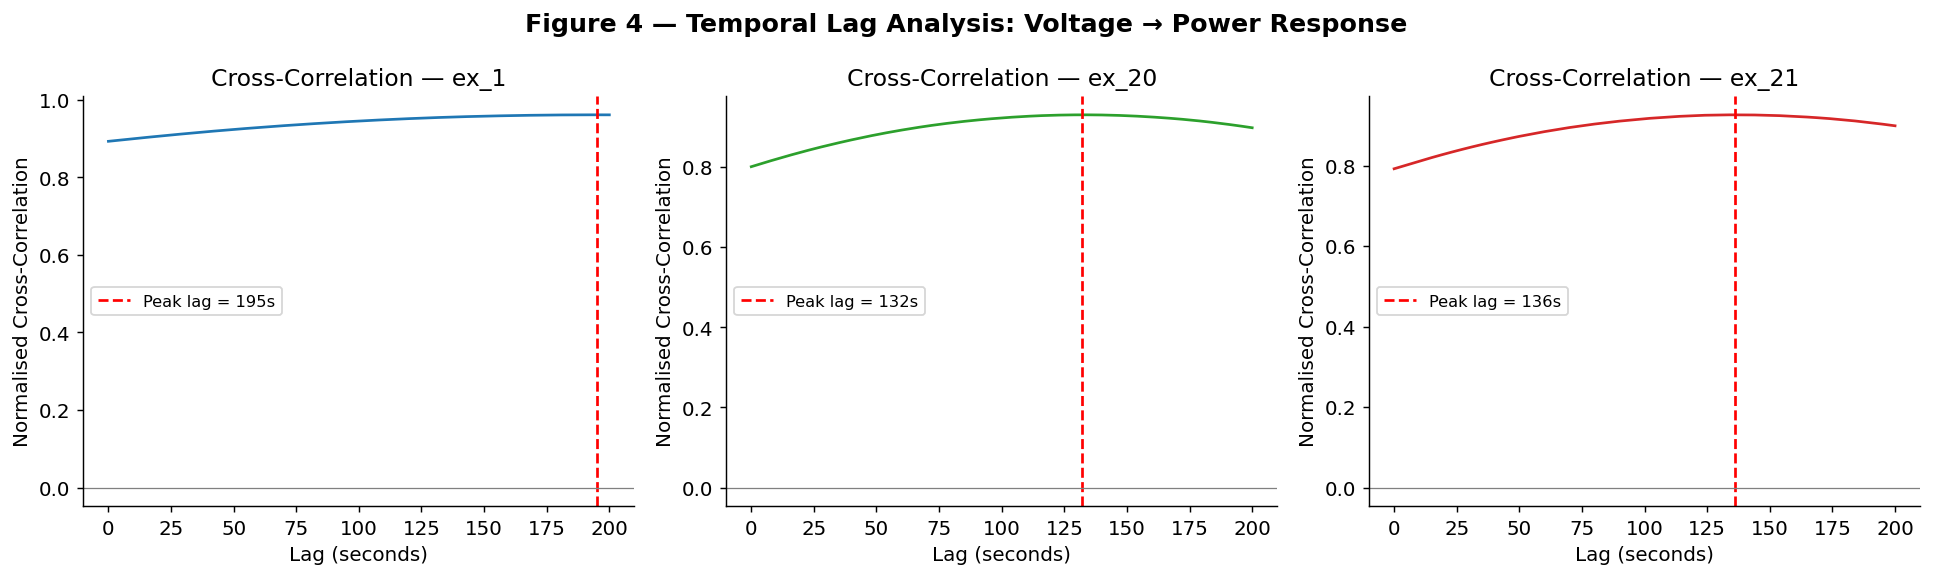

Detected peak lags: [195, 132, 136]  |  Mean lag: 154s


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Figure 4 — Temporal Lag Analysis: Voltage → Power Response',
             fontsize=14, fontweight='bold')

peak_lags = []
for i, eid in enumerate(TRAIN_EXPS[:3]):   # show 3 for clarity
    sub = df_train_raw[df_train_raw['experiment_id'] == eid].reset_index(drop=True)
    v_c = (sub['input_voltage'] - sub['input_voltage'].mean()).values
    p_c = (sub['el_power']      - sub['el_power'].mean()).values
    max_lag = 200
    xcorr   = np.correlate(p_c, v_c, mode='full')
    mid     = len(xcorr) // 2
    xc_sec  = xcorr[mid:mid+max_lag+1]
    xc_norm = xc_sec / (np.std(v_c) * np.std(p_c) * len(v_c))
    lags    = np.arange(0, max_lag+1)
    pk      = int(lags[np.argmax(xc_norm)])
    peak_lags.append(pk)

    axes[i].plot(lags, xc_norm, color=EXP_COLORS[eid], lw=1.5)
    axes[i].axvline(pk, color='red', linestyle='--', lw=1.5, label=f'Peak lag = {pk}s')
    axes[i].axhline(0, color='grey', lw=0.7)
    axes[i].set_title(f'Cross-Correlation — {eid}')
    axes[i].set_xlabel('Lag (seconds)')
    axes[i].set_ylabel('Normalised Cross-Correlation')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig04_cross_correlation.png')
plt.show()

mean_lag = int(np.mean(peak_lags))
print(f'Detected peak lags: {peak_lags}  |  Mean lag: {mean_lag}s')

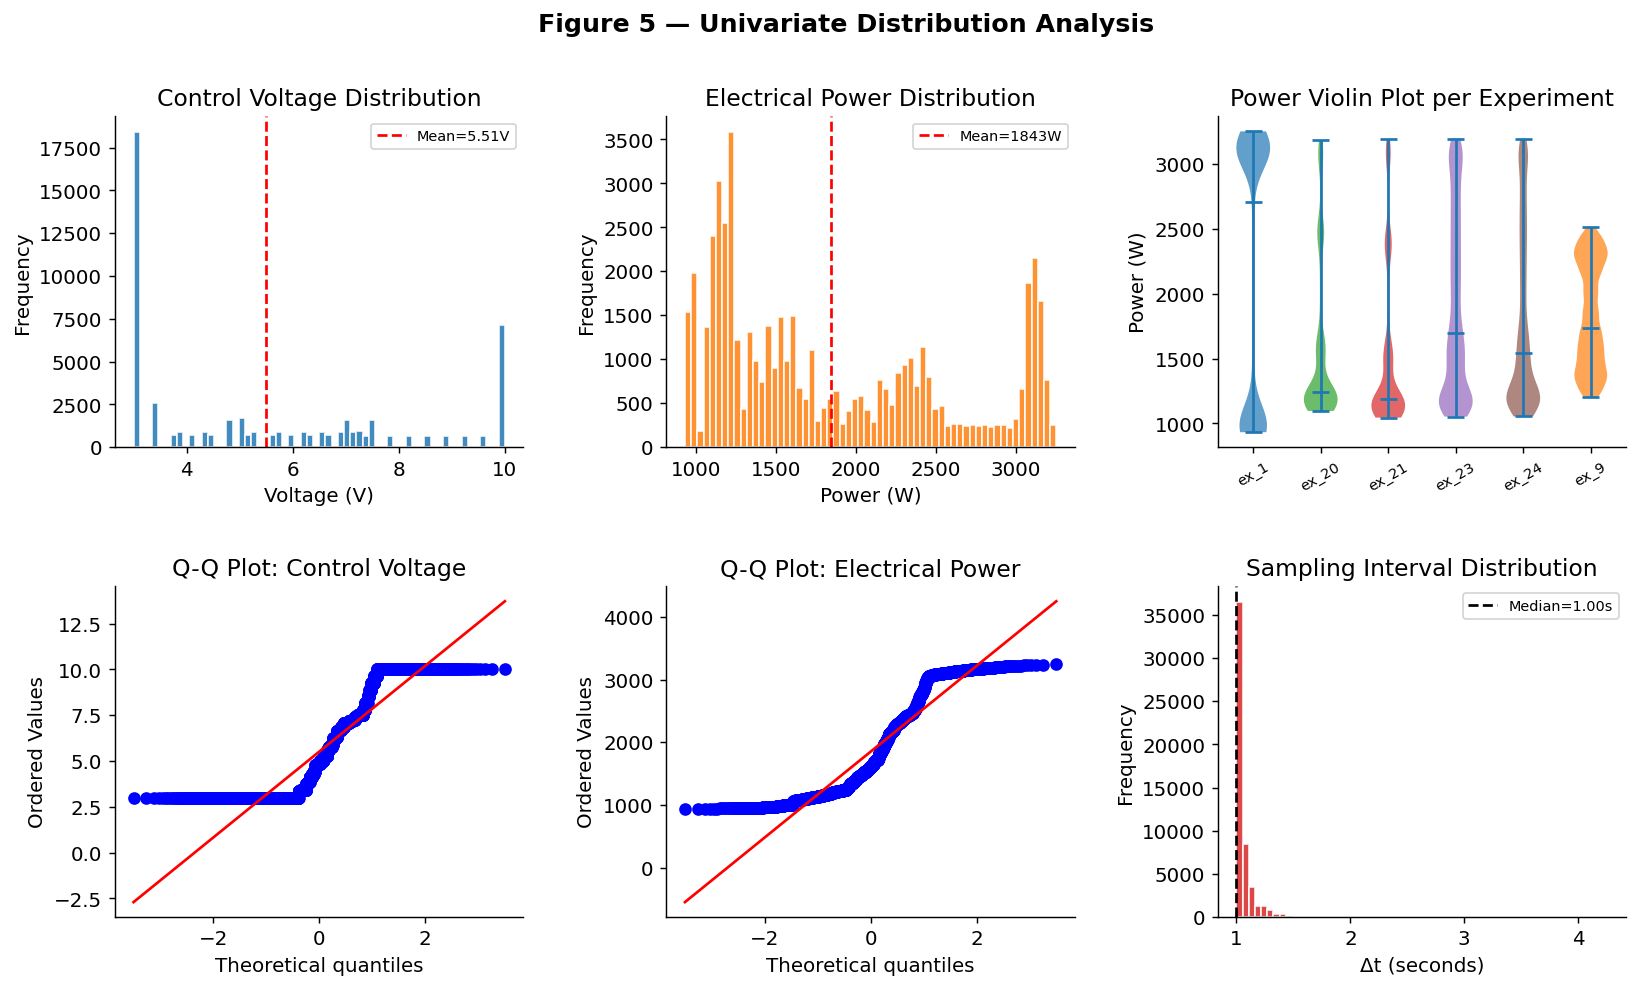

Voltage:  skewness=0.570, kurtosis=-1.093
Power:    skewness=0.586, kurtosis=-1.041
Δt (median): 1.000s  |  Δt (std): 0.0877s


In [22]:
fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
fig.suptitle('Figure 5 — Univariate Distribution Analysis', fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

v_all = df_train_raw['input_voltage']
p_all = df_train_raw['el_power']

ax1.hist(v_all, bins=60, color=PAL[0], edgecolor='white', alpha=0.85)
ax1.axvline(v_all.mean(), color='red', ls='--', lw=1.5, label=f'Mean={v_all.mean():.2f}V')
ax1.set_title('Control Voltage Distribution'); ax1.set_xlabel('Voltage (V)'); ax1.set_ylabel('Frequency'); ax1.legend(fontsize=8)

ax2.hist(p_all, bins=60, color=PAL[1], edgecolor='white', alpha=0.85)
ax2.axvline(p_all.mean(), color='red', ls='--', lw=1.5, label=f'Mean={p_all.mean():.0f}W')
ax2.set_title('Electrical Power Distribution'); ax2.set_xlabel('Power (W)'); ax2.set_ylabel('Frequency'); ax2.legend(fontsize=8)

# Power per experiment violin
viol_data = [df_train_raw[df_train_raw['experiment_id']==e]['el_power'].values for e in TRAIN_EXPS]
parts = ax3.violinplot(viol_data, positions=range(len(TRAIN_EXPS)), showmedians=True)
for pc, eid in zip(parts['bodies'], TRAIN_EXPS):
    pc.set_facecolor(EXP_COLORS[eid]); pc.set_alpha(0.7)
ax3.set_xticks(range(len(TRAIN_EXPS))); ax3.set_xticklabels(TRAIN_EXPS, rotation=30, fontsize=8)
ax3.set_title('Power Violin Plot per Experiment'); ax3.set_ylabel('Power (W)')

# Q-Q plots
samp_v = v_all.sample(3000, random_state=42)
samp_p = p_all.sample(3000, random_state=42)
stats.probplot(samp_v, dist='norm', plot=ax4); ax4.set_title('Q-Q Plot: Control Voltage'); ax4.get_lines()[1].set_color('red')
stats.probplot(samp_p, dist='norm', plot=ax5); ax5.set_title('Q-Q Plot: Electrical Power'); ax5.get_lines()[1].set_color('red')

# Time-step interval distribution
dt_vals = []
for eid in TRAIN_EXPS:
    sub = df_train_raw[df_train_raw['experiment_id']==eid].sort_values('time')
    dt_vals.extend(sub['time'].diff().dropna().values)
ax6.hist(dt_vals, bins=60, color=PAL[3], edgecolor='white', alpha=0.85)
ax6.set_title('Sampling Interval Distribution'); ax6.set_xlabel('Δt (seconds)'); ax6.set_ylabel('Frequency')
ax6.axvline(np.median(dt_vals), color='black', ls='--', lw=1.5, label=f'Median={np.median(dt_vals):.2f}s')
ax6.legend(fontsize=8)

plt.savefig('figures/fig05_distributions.png')
plt.show()

print(f'Voltage:  skewness={v_all.skew():.3f}, kurtosis={v_all.kurtosis():.3f}')
print(f'Power:    skewness={p_all.skew():.3f}, kurtosis={p_all.kurtosis():.3f}')
print(f'Δt (median): {np.median(dt_vals):.3f}s  |  Δt (std): {np.std(dt_vals):.4f}s')

### Feature Engineering

In [25]:
def engineer_features(df, window_smooth=21, poly_order=3):

    df = df.copy().sort_values('time').reset_index(drop=True)

    # 1. Smooth power signal (remove sensor noise)
    df['el_power_smooth'] = savgol_filter(
        df['el_power'].values, window_length=window_smooth, polyorder=poly_order
    )

    # 2. Rate-of-change features (finite differences)
    df['dV_dt'] = df['input_voltage'].diff()       # voltage change per second
    df['dP_dt'] = df['el_power_smooth'].diff()     # power change per second

    # 3. Lag features — voltage history
    for lag in [1, 5, 10]:
        df[f'voltage_lag_{lag}'] = df['input_voltage'].shift(lag)

    # 4. Lag features — power history (captures thermal lag window)
    for lag in [1, 5, 10, 30]:
        df[f'power_lag_{lag}'] = df['el_power_smooth'].shift(lag)

    # 5. Rolling statistics — 30-second window
    df['power_rolling_mean_30'] = df['el_power_smooth'].rolling(30, min_periods=5).mean()
    df['power_rolling_std_30']  = df['el_power_smooth'].rolling(30, min_periods=5).std().fillna(0)

    # Drop rows with NaN from lag/rolling operations
    df = df.dropna().reset_index(drop=True)
    return df


# Apply to each experiment independently
train_frames = []
for eid in TRAIN_EXPS:
    sub = df_train_raw[df_train_raw['experiment_id'] == eid]
    train_frames.append(engineer_features(sub))
df_train = pd.concat(train_frames, ignore_index=True)

test_frames = []
for eid in TEST_EXPS:
    sub = df_test_raw[df_test_raw['experiment_id'] == eid]
    test_frames.append(engineer_features(sub))
df_test = pd.concat(test_frames, ignore_index=True)

# Define state feature columns
STATE_FEATURES = [
    'input_voltage',
    'el_power_smooth',
    'dV_dt',
    'dP_dt',
    'voltage_lag_1',  'voltage_lag_5',  'voltage_lag_10',
    'power_lag_1',    'power_lag_5',    'power_lag_10',   'power_lag_30',
    'power_rolling_mean_30',
    'power_rolling_std_30',
]

print(f'Training set after feature engineering: {df_train.shape}')
print(f'Test set after feature engineering:     {df_test.shape}')
print(f'Number of state features: {len(STATE_FEATURES)}')
print(f'Features: {STATE_FEATURES}')
display(df_train[STATE_FEATURES].describe().round(3))

Training set after feature engineering: (52760, 16)
Test set after feature engineering:     (18225, 16)
Number of state features: 13
Features: ['input_voltage', 'el_power_smooth', 'dV_dt', 'dP_dt', 'voltage_lag_1', 'voltage_lag_5', 'voltage_lag_10', 'power_lag_1', 'power_lag_5', 'power_lag_10', 'power_lag_30', 'power_rolling_mean_30', 'power_rolling_std_30']


,input_voltage,el_power_smooth,dV_dt,dP_dt,voltage_lag_1,voltage_lag_5,voltage_lag_10,power_lag_1,power_lag_5,power_lag_10,power_lag_30,power_rolling_mean_30,power_rolling_std_30
count,52760.000,52760.000,52760.00,52760.000,52760.000,52760.000,52760.000,52760.000,52760.000,52760.000,52760.000,52760.000,52760.000
mean,5.510,1845.474,-0.00,0.010,5.510,5.510,5.510,1845.464,1845.421,1845.362,1845.100,1845.303,11.462
std,2.549,722.031,0.11,6.696,2.549,2.549,2.549,722.022,721.983,721.936,721.769,721.680,13.962
min,3.000,954.018,-7.00,-16.772,3.000,3.000,3.000,954.018,954.018,954.018,954.018,955.375,0.506
25%,3.000,1181.758,0.00,-6.265,3.000,3.000,3.000,1181.763,1181.788,1181.814,1182.018,1182.224,4.489
50%,5.000,1583.212,0.00,-0.060,5.000,5.000,5.000,1583.175,1583.097,1583.036,1582.763,1581.887,6.097
75%,7.421,2386.645,0.00,6.507,7.421,7.421,7.421,2386.645,2386.624,2386.572,2386.099,2387.104,10.900
max,10.000,3232.550,7.00,17.612,10.000,10.000,10.000,3232.550,3232.550,3232.550,3232.550,3229.839,69.374


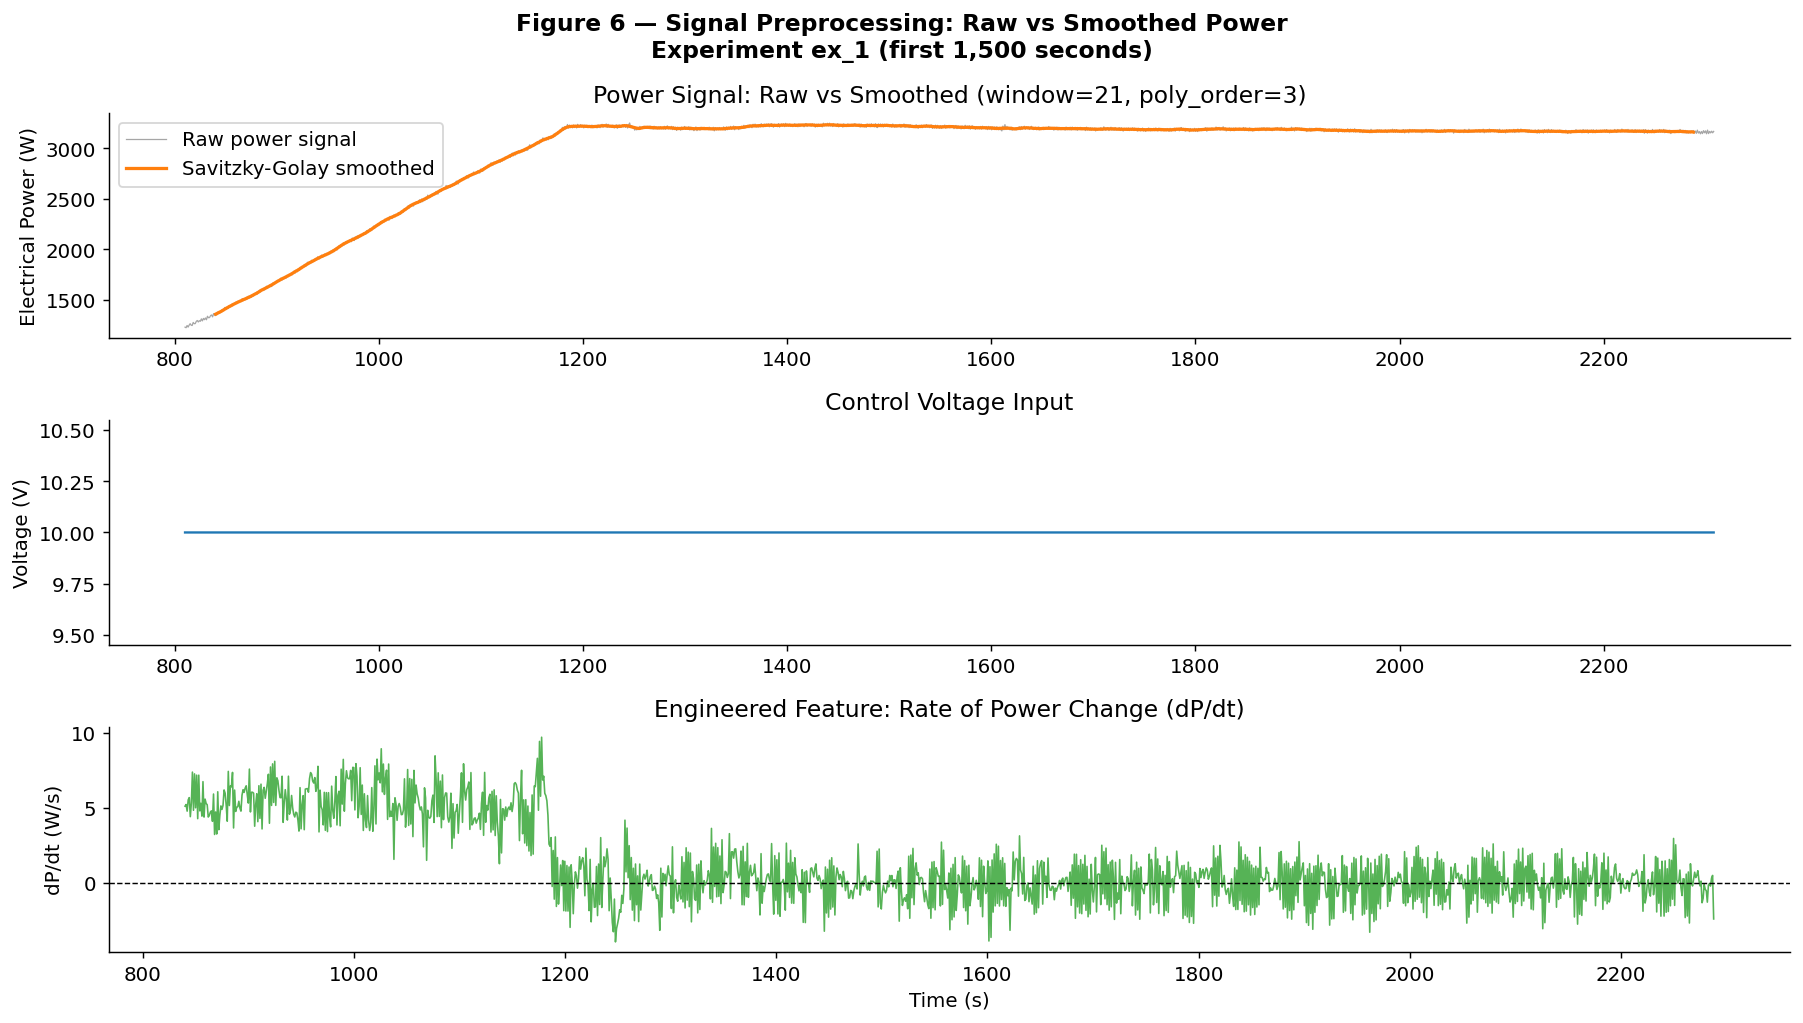

In [27]:
sample_eid = 'ex_1'
raw_sub  = df_train_raw[df_train_raw['experiment_id'] == sample_eid].sort_values('time').head(1500)
eng_sub  = df_train[df_train['experiment_id'] == sample_eid].head(1450)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
fig.suptitle(f'Figure 6 — Signal Preprocessing: Raw vs Smoothed Power\n'
             f'Experiment {sample_eid} (first 1,500 seconds)', fontsize=13, fontweight='bold')

t_raw = raw_sub['time'].values
t_eng = eng_sub['time'].values

axes[0].plot(t_raw, raw_sub['el_power'], color='grey', lw=0.7, alpha=0.7, label='Raw power signal')
axes[0].plot(t_eng, eng_sub['el_power_smooth'], color=PAL[1], lw=1.8, label='Savitzky-Golay smoothed')
axes[0].set_ylabel('Electrical Power (W)')
axes[0].set_title('Power Signal: Raw vs Smoothed (window=21, poly_order=3)')
axes[0].legend()

axes[1].plot(t_raw, raw_sub['input_voltage'], color=PAL[0], lw=1.3)
axes[1].set_ylabel('Voltage (V)')
axes[1].set_title('Control Voltage Input')

axes[2].plot(t_eng, eng_sub['dP_dt'], color=PAL[2], lw=0.9, alpha=0.8)
axes[2].axhline(0, color='black', lw=0.8, linestyle='--')
axes[2].set_ylabel('dP/dt (W/s)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Engineered Feature: Rate of Power Change (dP/dt)')

plt.tight_layout()
plt.savefig('figures/fig06_smoothing_features.png')
plt.show()

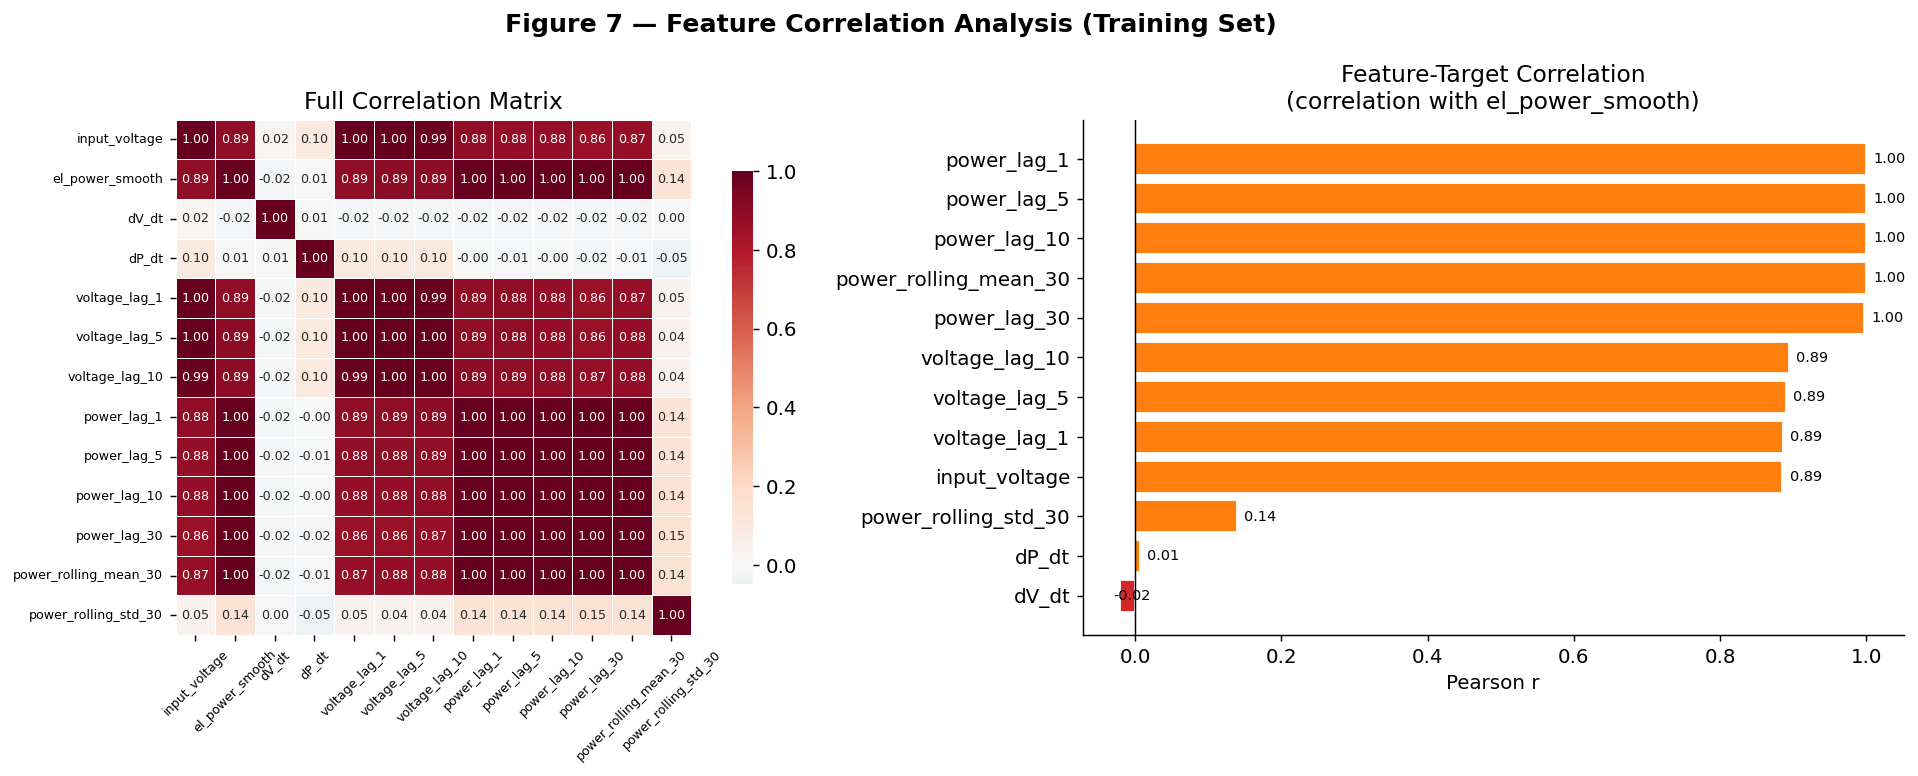


Top features by correlation with target:
power_lag_1              1.000
power_lag_5              1.000
power_lag_10             1.000
power_rolling_mean_30    0.999
power_lag_30             0.997
voltage_lag_10           0.894
voltage_lag_5            0.890
voltage_lag_1            0.886
input_voltage            0.885
power_rolling_std_30     0.139
dV_dt                    0.021
dP_dt                    0.006


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 7 — Feature Correlation Analysis (Training Set)',
             fontsize=14, fontweight='bold')

corr = df_train[STATE_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, square=True,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
axes[0].set_title('Full Correlation Matrix')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# Feature-target correlation bar chart
target_corr = corr['el_power_smooth'].drop('el_power_smooth').sort_values()
colors_bar  = [PAL[1] if v > 0 else PAL[3] for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Feature-Target Correlation\n(correlation with el_power_smooth)')
axes[1].set_xlabel('Pearson r')
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(val + 0.01 * np.sign(val), i, f'{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig07_correlation_heatmap.png')
plt.show()

print("\nTop features by correlation with target:")
print(target_corr.abs().sort_values(ascending=False).round(3).to_string())

### Scaling

In [46]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(df_train[STATE_FEATURES])

df_train_scaled = df_train.copy()
df_test_scaled  = df_test.copy()
df_train_scaled[STATE_FEATURES] = scaler.transform(df_train[STATE_FEATURES])
df_test_scaled[STATE_FEATURES]  = scaler.transform(df_test[STATE_FEATURES])

# Scale power target for reward computation
P_MIN = df_train['el_power_smooth'].min()
P_MAX = df_train['el_power_smooth'].max()
V_MIN = df_train['input_voltage'].min()
V_MAX = df_train['input_voltage'].max()

print('Scaling complete (fit on training set only).')
print(f'Power range: [{P_MIN:.1f}, {P_MAX:.1f}] W → [0, 1]')
print(f'Voltage range: [{V_MIN:.1f}, {V_MAX:.1f}] V → [0, 1]')
print(f'Training features after scaling — min: {df_train_scaled[STATE_FEATURES].values.min():.4f},',
      f'max: {df_train_scaled[STATE_FEATURES].values.max():.4f}')

Scaling complete (fit on training set only).
Power range: [954.0, 3232.6] W → [0, 1]
Voltage range: [3.0, 10.0] V → [0, 1]
Training features after scaling — min: 0.0000, max: 1.0000


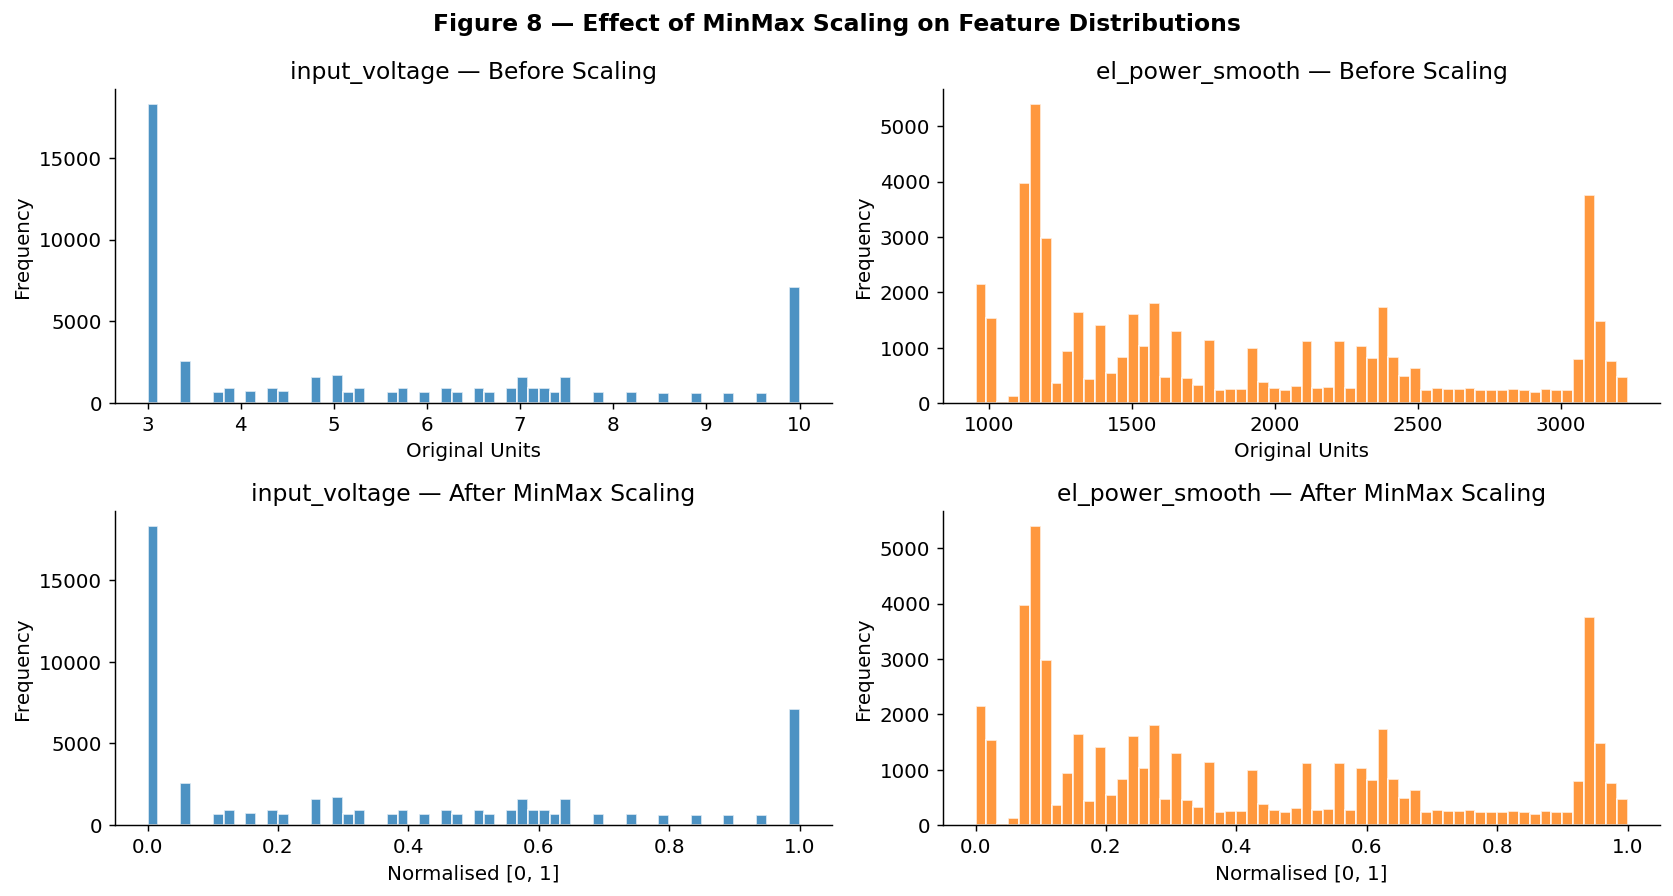

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('Figure 8 — Effect of MinMax Scaling on Feature Distributions',
             fontsize=13, fontweight='bold')

for ax, feat, col, label in [
    (axes[0,0], 'input_voltage',    PAL[0], 'Raw'),
    (axes[0,1], 'el_power_smooth',  PAL[1], 'Raw'),
]:
    ax.hist(df_train[feat], bins=60, color=col, edgecolor='white', alpha=0.8)
    ax.set_title(f'{feat} — Before Scaling'); ax.set_xlabel('Original Units'); ax.set_ylabel('Frequency')

for ax, feat, col in [
    (axes[1,0], 'input_voltage',    PAL[0]),
    (axes[1,1], 'el_power_smooth',  PAL[1]),
]:
    ax.hist(df_train_scaled[feat], bins=60, color=col, edgecolor='white', alpha=0.8)
    ax.set_title(f'{feat} — After MinMax Scaling'); ax.set_xlabel('Normalised [0, 1]'); ax.set_ylabel('Frequency')
    ax.set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('figures/fig08_scaling.png')
plt.show()

### Custom Gymnasium Environment

In [51]:
class MicroGasTurbineEnv(gym.Env):
    """
    Custom Gymnasium environment for RL-based micro gas turbine control.

    The environment replays real experimental data. At each timestep the agent
    receives the current turbine state and outputs a continuous voltage adjustment.
    The turbine's response (power) comes directly from the real dataset, ensuring
    the agent is evaluated against actual measured system dynamics.

    Observation Space (13-dim, all values in [0, 1] after MinMax scaling):
        [input_voltage, el_power_smooth, dV_dt, dP_dt,
         voltage_lag_1, voltage_lag_5, voltage_lag_10,
         power_lag_1, power_lag_5, power_lag_10, power_lag_30,
         power_rolling_mean_30, power_rolling_std_30]

    Action Space (1-dim, continuous in [-1, 1]):
        Scaled to voltage delta: delta_V = action * 0.5 (so ±0.5 V per step)

    Reward Function:
        r_t = w1 * P_norm                        # maximise power output
             - w2 * |delta_V|                    # penalise fuel use (large actions)
             - w3 * |dP_dt_norm|                 # penalise instability
             - w4 * boundary_penalty             # penalise hitting voltage limits

        where w1=1.0, w2=0.05, w3=0.03, w4=5.0

    Parameters
    ----------
    data_df    : Scaled DataFrame (output of MinMaxScaler pipeline)
    state_cols : List of feature column names
    episode_len: Number of timesteps per episode
    """

    metadata = {'render_modes': []}

    # Reward weights
    W_POWER    = 1.00
    W_ACTION   = 0.05
    W_STABILITY= 0.03
    W_BOUNDARY = 5.00

    def __init__(self, data_df, state_cols, episode_len=600):
        super().__init__()

        self.data        = data_df.reset_index(drop=True)
        self.state_cols  = state_cols
        self.episode_len = episode_len
        self.n           = len(self.data)

        # Observation space: 13 features, all normalised to [0, 1]
        self.observation_space = spaces.Box(
            low   = np.zeros(len(state_cols), dtype=np.float32),
            high  = np.ones (len(state_cols), dtype=np.float32),
            dtype = np.float32
        )

        # Action space: continuous voltage delta [-1, 1] (scaled to ±0.5 V)
        self.action_space = spaces.Box(
            low   = np.array([-1.0], dtype=np.float32),
            high  = np.array([ 1.0], dtype=np.float32),
            dtype = np.float32
        )

        # Tracking variables
        self.current_idx    = 0
        self.step_count     = 0
        self.current_voltage= 0.0
        self.current_power  = 0.0
        self.reward_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Random starting position, leaving room for the episode
        max_start = max(0, self.n - self.episode_len - 1)
        self.current_idx     = int(self.np_random.integers(0, max_start)) if max_start > 0 else 0
        self.step_count      = 0
        self.current_voltage = float(self.data.loc[self.current_idx, 'input_voltage'])
        self.reward_history  = []
        return self._get_obs(), {}

    def _get_obs(self):
        idx = min(self.current_idx, self.n - 1)
        obs = self.data.loc[idx, self.state_cols].values.astype(np.float32)
        return np.clip(obs, 0.0, 1.0)

    def step(self, action):
        action = float(np.clip(action, -1.0, 1.0))
        delta_v = action * 0.5   # scale: [-1,1] → [-0.5, 0.5] V

        # Update voltage (bounded to [0, 1] normalised = [3, 10] V raw)
        self.current_voltage = float(np.clip(self.current_voltage + delta_v * (1/7), 0.0, 1.0))

        # Advance data index
        self.current_idx += 1
        self.step_count  += 1
        done = (self.step_count >= self.episode_len) or (self.current_idx >= self.n - 1)

        row = self.data.loc[min(self.current_idx, self.n - 1)]
        P_norm  = float(row['el_power_smooth'])      # already in [0,1]
        dP_norm = float(row['dP_dt']) if 'dP_dt' in row.index else 0.0
        self.current_power = P_norm

        # ── Reward function ─────────────────────────────────────
        v = self.current_voltage
        r_power    =  self.W_POWER     * P_norm
        r_action   = -self.W_ACTION    * abs(action)
        r_stability= -self.W_STABILITY * abs(dP_norm)
        r_boundary = -self.W_BOUNDARY  * (max(0.0, v - 0.97) + max(0.0, 0.03 - v))
        reward     = r_power + r_action + r_stability + r_boundary
        self.reward_history.append(reward)

        obs = self._get_obs()
        info = {
            'power_norm'   : P_norm,
            'power_W'      : P_norm * (P_MAX - P_MIN) + P_MIN,
            'action'       : action,
            'voltage_norm' : v,
            'voltage_V'    : v * (V_MAX - V_MIN) + V_MIN,
            'r_power'      : r_power,
            'r_action'     : r_action,
            'r_stability'  : r_stability,
            'r_boundary'   : r_boundary,
        }
        return obs, reward, done, False, info

    def render(self):
        pass


# ── Instantiate environments ───────────────────────────────────
env_train = MicroGasTurbineEnv(df_train_scaled, STATE_FEATURES, episode_len=600)
env_test  = MicroGasTurbineEnv(df_test_scaled,  STATE_FEATURES, episode_len=600)

# Sanity check
obs, _ = env_train.reset(seed=0)
print(f'Observation space: {env_train.observation_space}')
print(f'Action space:      {env_train.action_space}')
print(f'Sample observation shape: {obs.shape}')
print(f'Sample observation (first 5 features): {obs[:5].round(4)}')

# Test one step
obs2, r, done, _, info = env_train.step(np.array([0.3]))
print(f'After one step — reward={r:.4f}, power={info["power_W"]:.1f}W, voltage={info["voltage_V"]:.2f}V')

Observation space: Box(0.0, 1.0, (13,), float32)
Action space:      Box(-1.0, 1.0, (1,), float32)
Sample observation shape: (13,)
Sample observation (first 5 features): [0.1864 0.2453 0.5    0.7114 0.1864]
After one step — reward=0.2189, power=1505.6W, voltage=4.45V


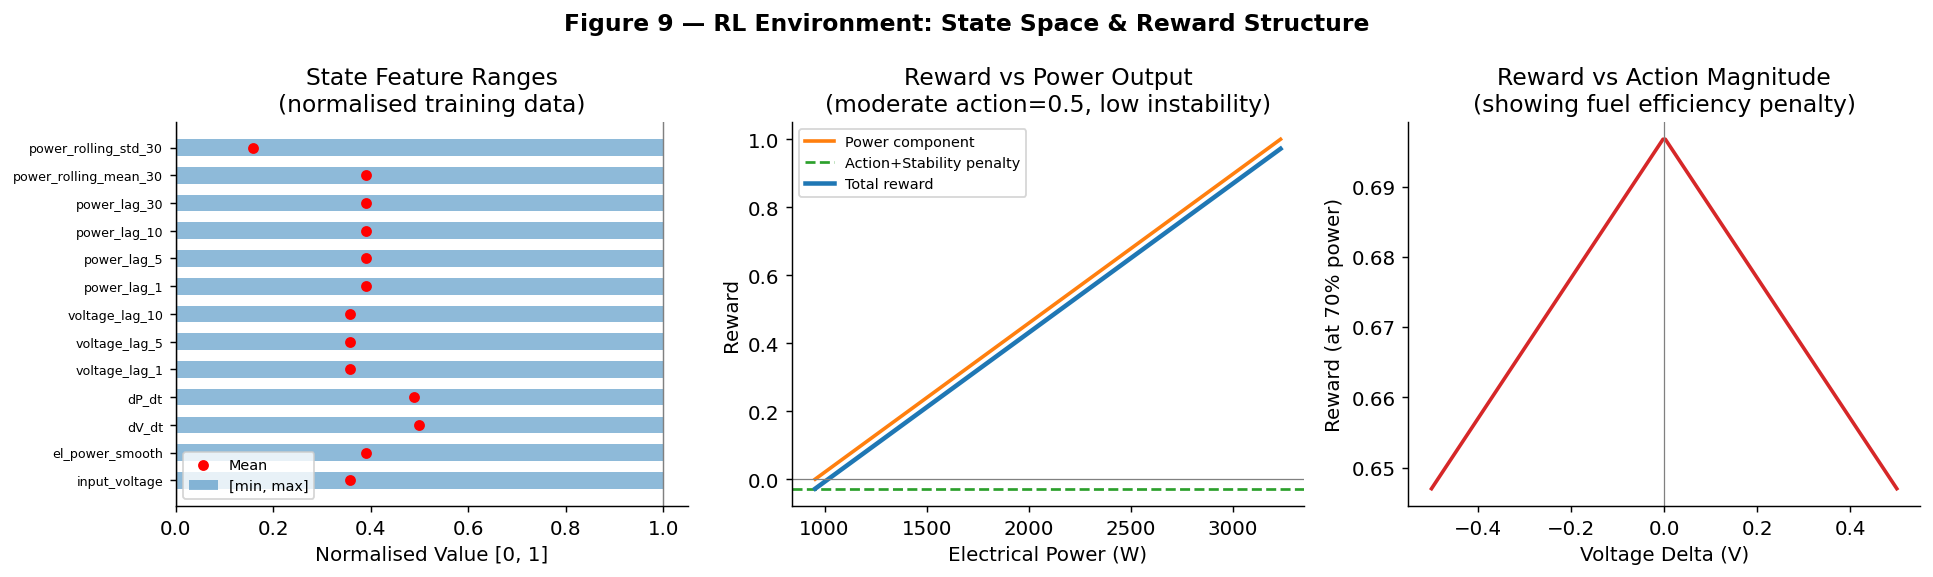

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Figure 9 — RL Environment: State Space & Reward Structure',
             fontsize=13, fontweight='bold')

# Panel 1: State feature ranges in training data
feat_mins = df_train_scaled[STATE_FEATURES].min()
feat_maxs = df_train_scaled[STATE_FEATURES].max()
feat_means= df_train_scaled[STATE_FEATURES].mean()
y_pos = np.arange(len(STATE_FEATURES))
axes[0].barh(y_pos, feat_maxs - feat_mins, left=feat_mins,
             color=PAL[0], alpha=0.5, height=0.6, label='[min, max]')
axes[0].scatter(feat_means, y_pos, color='red', zorder=5, s=25, label='Mean')
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(STATE_FEATURES, fontsize=7)
axes[0].set_xlabel('Normalised Value [0, 1]')
axes[0].set_title('State Feature Ranges\n(normalised training data)')
axes[0].legend(fontsize=8)
axes[0].axvline(0, color='grey', lw=0.8); axes[0].axvline(1, color='grey', lw=0.8)

# Panel 2: Reward landscape vs power level
p_vals = np.linspace(0, 1, 200)
r_pow  = 1.0 * p_vals
r_act  = -0.05 * 0.5   # fixed moderate action
r_stab = -0.03 * 0.1   # fixed low instability
r_total= r_pow + r_act + r_stab
axes[1].plot(p_vals * (P_MAX-P_MIN)+P_MIN, r_pow,   color=PAL[1], lw=2, label='Power component')
axes[1].axhline(r_act + r_stab, color=PAL[2], lw=1.5, linestyle='--', label='Action+Stability penalty')
axes[1].plot(p_vals * (P_MAX-P_MIN)+P_MIN, r_total, color=PAL[0], lw=2.5, label='Total reward')
axes[1].set_xlabel('Electrical Power (W)')
axes[1].set_ylabel('Reward')
axes[1].set_title('Reward vs Power Output\n(moderate action=0.5, low instability)')
axes[1].legend(fontsize=8)
axes[1].axhline(0, color='grey', lw=0.7)

# Panel 3: Reward landscape vs action magnitude
a_vals = np.linspace(-1, 1, 200)
r_by_action = 0.7 - 0.05 * abs(a_vals) - 0.03 * 0.1
axes[2].plot(a_vals * 0.5, r_by_action, color=PAL[3], lw=2)
axes[2].set_xlabel('Voltage Delta (V)')
axes[2].set_ylabel('Reward (at 70% power)')
axes[2].set_title('Reward vs Action Magnitude\n(showing fuel efficiency penalty)')
axes[2].axvline(0, color='grey', lw=0.7)

plt.tight_layout()
plt.savefig('figures/fig09_environment_design.png')
plt.show()


### RL Agent Training

In [56]:
class RewardLogger(BaseCallback):
    """
    Custom SB3 callback that records the cumulative reward at the
    end of every episode during training. Used to plot training curves.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.ep_rewards   = []
        self.ep_powers    = []
        self._cur_reward  = 0.0
        self._cur_steps   = 0

    def _on_step(self) -> bool:
        self._cur_reward += float(self.locals['rewards'][0])
        self._cur_steps  += 1
        infos = self.locals.get('infos', [{}])
        if self.locals['dones'][0]:
            self.ep_rewards.append(self._cur_reward)
            self._cur_reward = 0.0
            self._cur_steps  = 0
        return True

In [60]:
TOTAL_TIMESTEPS = 150_000   # increase for better performance

print('=' * 55)
print('  Training PPO Agent')
print('  Total timesteps:', f'{TOTAL_TIMESTEPS:,}')
print('=' * 55)

ppo_cb = RewardLogger()
ppo_model = PPO(
    policy             = 'MlpPolicy',
    env                = env_train,
    learning_rate      = 3e-4,
    n_steps            = 2048,      # steps per rollout
    batch_size         = 64,
    n_epochs           = 10,        # PPO update epochs per rollout
    gamma              = 0.99,      # discount factor
    gae_lambda         = 0.95,      # GAE smoothing
    clip_range         = 0.2,       # PPO clip parameter
    ent_coef           = 0.01,      # entropy bonus for exploration
    vf_coef            = 0.5,       # value function loss weight
    policy_kwargs      = dict(net_arch=[128, 128]),  # 2-layer MLP
    verbose            = 1,
    seed               = 42,
)

ppo_model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=ppo_cb, progress_bar=False)
ppo_model.save('models/ppo_turbine')
np.save('models/ppo_rewards.npy', np.array(ppo_cb.ep_rewards))

print(f'\nPPO training complete. Episodes: {len(ppo_cb.ep_rewards)}')
print(f'Final 10-episode mean reward: {np.mean(ppo_cb.ep_rewards[-10:]):.2f}')

  Training PPO Agent
  Total timesteps: 150,000
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 600      |
|    ep_rew_mean     | 85.4     |
| time/              |          |
|    fps             | 485      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 600          |
|    ep_rew_mean          | 68.3         |
| time/                   |              |
|    fps                  | 386          |
|    iterations           | 2            |
|    time_elapsed         | 10           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0031993112 |
|    clip_fraction        | 0.0117       |
| 

In [62]:
print('=' * 55)
print('  Training DDPG Agent')
print('  Total timesteps:', f'{TOTAL_TIMESTEPS:,}')
print('=' * 55)

# Gaussian exploration noise for DDPG
n_actions   = env_train.action_space.shape[-1]
action_noise= NormalActionNoise(
    mean  = np.zeros(n_actions),
    sigma = 0.15 * np.ones(n_actions)
)

ddpg_cb = RewardLogger()
ddpg_model = DDPG(
    policy             = 'MlpPolicy',
    env                = env_train,
    learning_rate      = 1e-3,
    buffer_size        = 50_000,    # experience replay buffer
    learning_starts    = 1000,      # steps before first update
    batch_size         = 128,
    tau                = 0.005,     # soft target update coefficient
    gamma              = 0.99,
    action_noise       = action_noise,
    policy_kwargs      = dict(net_arch=[128, 128]),
    verbose            = 1,
    seed               = 42,
)

ddpg_model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=ddpg_cb, progress_bar=False)
ddpg_model.save('models/ddpg_turbine')
np.save('models/ddpg_rewards.npy', np.array(ddpg_cb.ep_rewards))

print(f'\nDDPG training complete. Episodes: {len(ddpg_cb.ep_rewards)}')
print(f'Final 10-episode mean reward: {np.mean(ddpg_cb.ep_rewards[-10:]):.2f}')

  Training DDPG Agent
  Total timesteps: 150,000
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 600      |
|    ep_rew_mean     | 52.9     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 160      |
|    time_elapsed    | 14       |
|    total_timesteps | 2400     |
| train/             |          |
|    actor_loss      | -0.725   |
|    critic_loss     | 0.0028   |
|    learning_rate   | 0.001    |
|    n_updates       | 1399     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 600      |
|    ep_rew_mean     | 34.6     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 118      |
|    time_elapsed    | 40       |
|    total_timesteps | 4800     |
| train/             |          |
|    ac

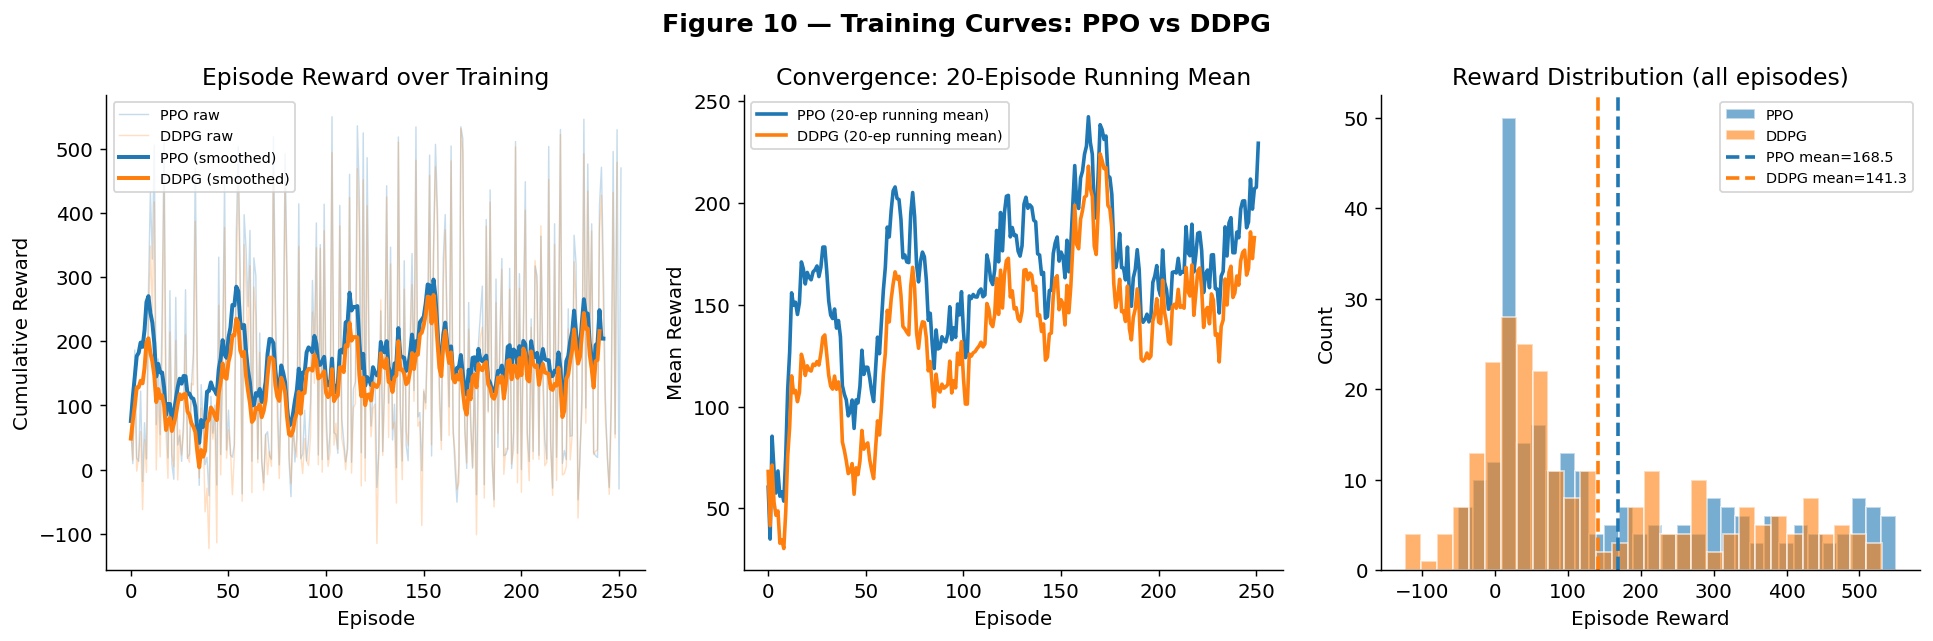

PPO  — Mean: 168.48  Std: 174.70  Final 10: 204.13
DDPG — Mean: 141.28  Std: 164.38  Final 10: 215.73


In [64]:
ppo_r  = np.load('models/ppo_rewards.npy')
ddpg_r = np.load('models/ddpg_rewards.npy')

def smooth(x, w=10):
    if len(x) < w: return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 10 — Training Curves: PPO vs DDPG', fontsize=14, fontweight='bold')

# Raw + smoothed reward
axes[0].plot(ppo_r,  alpha=0.25, color=PAL[0], lw=0.8, label='PPO raw')
axes[0].plot(ddpg_r, alpha=0.25, color=PAL[1], lw=0.8, label='DDPG raw')
axes[0].plot(smooth(ppo_r),  color=PAL[0], lw=2.2, label='PPO (smoothed)')
axes[0].plot(smooth(ddpg_r), color=PAL[1], lw=2.2, label='DDPG (smoothed)')
axes[0].set_title('Episode Reward over Training'); axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Cumulative Reward')
axes[0].legend(fontsize=8)

# Convergence check: running mean
ppo_running  = np.array([np.mean(ppo_r[max(0,i-20):i+1]) for i in range(len(ppo_r))])
ddpg_running = np.array([np.mean(ddpg_r[max(0,i-20):i+1]) for i in range(len(ddpg_r))])
axes[1].plot(ppo_running,  color=PAL[0], lw=2, label='PPO (20-ep running mean)')
axes[1].plot(ddpg_running, color=PAL[1], lw=2, label='DDPG (20-ep running mean)')
axes[1].set_title('Convergence: 20-Episode Running Mean'); axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Mean Reward')
axes[1].legend(fontsize=8)

# Episode reward distribution
axes[2].hist(ppo_r,  bins=30, color=PAL[0], alpha=0.6, label='PPO',  edgecolor='white')
axes[2].hist(ddpg_r, bins=30, color=PAL[1], alpha=0.6, label='DDPG', edgecolor='white')
axes[2].axvline(ppo_r.mean(),  color=PAL[0], lw=2, linestyle='--', label=f'PPO mean={ppo_r.mean():.1f}')
axes[2].axvline(ddpg_r.mean(), color=PAL[1], lw=2, linestyle='--', label=f'DDPG mean={ddpg_r.mean():.1f}')
axes[2].set_title('Reward Distribution (all episodes)'); axes[2].set_xlabel('Episode Reward'); axes[2].set_ylabel('Count')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig10_training_curves.png')
plt.show()

print(f'PPO  — Mean: {ppo_r.mean():.2f}  Std: {ppo_r.std():.2f}  Final 10: {ppo_r[-10:].mean():.2f}')
print(f'DDPG — Mean: {ddpg_r.mean():.2f}  Std: {ddpg_r.std():.2f}  Final 10: {ddpg_r[-10:].mean():.2f}')


In [66]:
def run_episode(env, policy_fn, n_episodes=5, seed=0):
    """
    Run a policy for n_episodes on env and collect detailed metrics.

    Parameters
    ----------
    env       : MicroGasTurbineEnv instance
    policy_fn : Callable(obs) → action
    n_episodes: Number of evaluation episodes
    seed      : Random seed for reproducibility

    Returns
    -------
    dict with keys: rewards, powers_W, actions, voltages_V
    """
    all_rewards = []; all_powers = []; all_actions = []; all_voltages = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_r, ep_p, ep_a, ep_v = [], [], [], []
        done = False
        while not done:
            action = policy_fn(obs)
            obs, r, done, _, info = env.step(action)
            ep_r.append(r)
            ep_p.append(info['power_W'])
            ep_a.append(info['action'])
            ep_v.append(info['voltage_V'])
        all_rewards.append(ep_r)
        all_powers.append(ep_p)
        all_actions.append(ep_a)
        all_voltages.append(ep_v)
    return dict(
        rewards   = all_rewards,
        powers_W  = all_powers,
        actions   = all_actions,
        voltages_V= all_voltages,
        mean_reward   = np.mean([sum(r) for r in all_rewards]),
        std_reward    = np.std( [sum(r) for r in all_rewards]),
        mean_power_W  = np.mean([np.mean(p) for p in all_powers]),
        mean_action_mag=np.mean([np.mean(np.abs(a)) for a in all_actions]),
    )

# Load trained models
ppo_loaded  = PPO.load('models/ppo_turbine',  env=env_test)
ddpg_loaded = DDPG.load('models/ddpg_turbine', env=env_test)

# Define all policies
def ppo_policy(obs):    return ppo_loaded.predict(obs, deterministic=True)[0]
def ddpg_policy(obs):   return ddpg_loaded.predict(obs, deterministic=True)[0]
def pid_policy(obs):
    """Simple P-controller: push voltage up if power below midpoint, down if above."""
    power_norm = float(obs[1])  # el_power_smooth feature
    error = 0.75 - power_norm   # target = 75% of max power
    return np.array([np.clip(error * 2.0, -1.0, 1.0)])
def const_policy(obs):  return np.array([0.5])       # constant moderate action
def random_policy(obs): return env_test.action_space.sample()

print('Evaluating all policies on test set...')
policies = {
    'PPO'     : ppo_policy,
    'DDPG'    : ddpg_policy,
    'PID'     : pid_policy,
    'Constant': const_policy,
    'Random'  : random_policy,
}

results = {}
for name, fn in policies.items():
    results[name] = run_episode(env_test, fn, n_episodes=5, seed=7)
    print(f'  {name:10s} | Mean Reward: {results[name]["mean_reward"]:8.2f} ± {results[name]["std_reward"]:.2f}'
          f' | Mean Power: {results[name]["mean_power_W"]:7.1f} W'
          f' | Action Mag: {results[name]["mean_action_mag"]:.3f}')

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Evaluating all policies on test set...
  PPO        | Mean Reward:   226.91 ± 155.13 | Mean Power:  2060.5 W | Action Mag: 0.037
  DDPG       | Mean Reward:   190.30 ± 142.77 | Mean Power:  2060.5 W | Action Mag: 0.456
  PID        | Mean Reward:   184.83 ± 163.43 | Mean Power:  2060.5 W | Action Mag: 0.575
  Constant   | Mean Reward:   179.83 ± 150.72 | Mean Power:  2060.5 W | Action Mag: 0.500
  Random     | Mean Reward:   257.71 ± 155.37 | Mean Power:  2060.5 W | Action Mag: 0.492


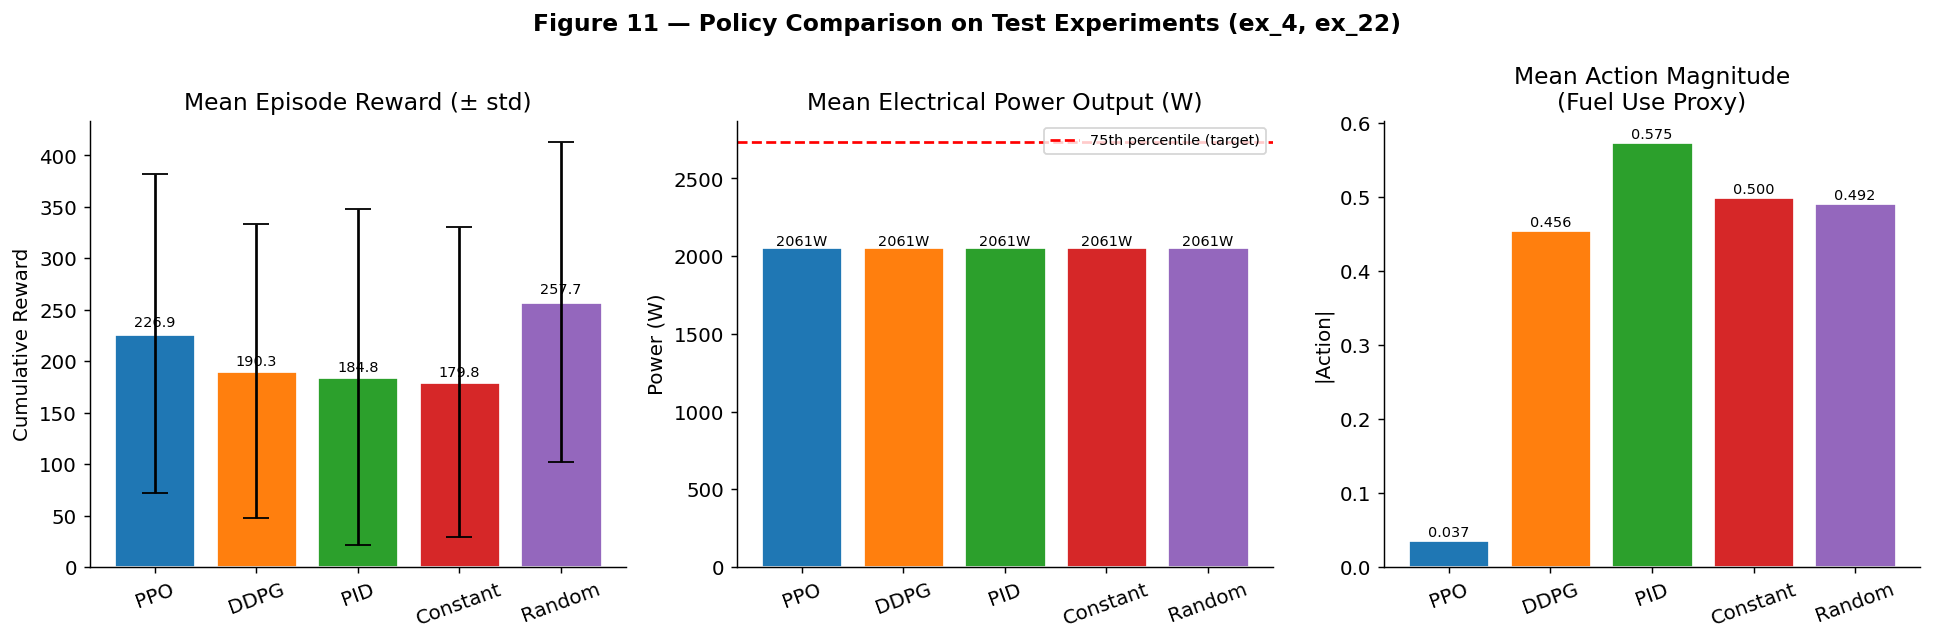


Improvement over PID baseline:
  PPO       : +0.0%
  DDPG      : +0.0%
  PID       : +0.0%
  Constant  : +0.0%
  Random    : +0.0%


In [68]:
names  = list(results.keys())
colors = [PAL[0], PAL[1], PAL[2], PAL[3], PAL[4]]

m_rew  = [results[n]['mean_reward']    for n in names]
s_rew  = [results[n]['std_reward']     for n in names]
m_pow  = [results[n]['mean_power_W']   for n in names]
m_act  = [results[n]['mean_action_mag']for n in names]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 11 — Policy Comparison on Test Experiments (ex_4, ex_22)',
             fontsize=13, fontweight='bold')

bars0 = axes[0].bar(names, m_rew, color=colors, yerr=s_rew, capsize=7, edgecolor='white', lw=1.5)
axes[0].set_title('Mean Episode Reward (± std)')
axes[0].set_ylabel('Cumulative Reward')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars0, m_rew):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+abs(bar.get_height())*0.03,
                 f'{val:.1f}', ha='center', fontsize=8)

bars1 = axes[1].bar(names, m_pow, color=colors, edgecolor='white', lw=1.5)
axes[1].axhline(np.percentile(df_test['el_power_smooth'], 75), color='red',
                linestyle='--', lw=1.5, label='75th percentile (target)')
axes[1].set_title('Mean Electrical Power Output (W)')
axes[1].set_ylabel('Power (W)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8)
for bar, val in zip(bars1, m_pow):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:.0f}W', ha='center', fontsize=8)

bars2 = axes[2].bar(names, m_act, color=colors, edgecolor='white', lw=1.5)
axes[2].set_title('Mean Action Magnitude\n(Fuel Use Proxy)')
axes[2].set_ylabel('|Action|')
axes[2].tick_params(axis='x', rotation=20)
for bar, val in zip(bars2, m_act):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig11_policy_comparison.png')
plt.show()

# Improvement table
baseline_pow = results['PID']['mean_power_W']
print('\nImprovement over PID baseline:')
for n in names:
    imp = (results[n]['mean_power_W'] - baseline_pow) / baseline_pow * 100
    print(f'  {n:10s}: {imp:+.1f}%')

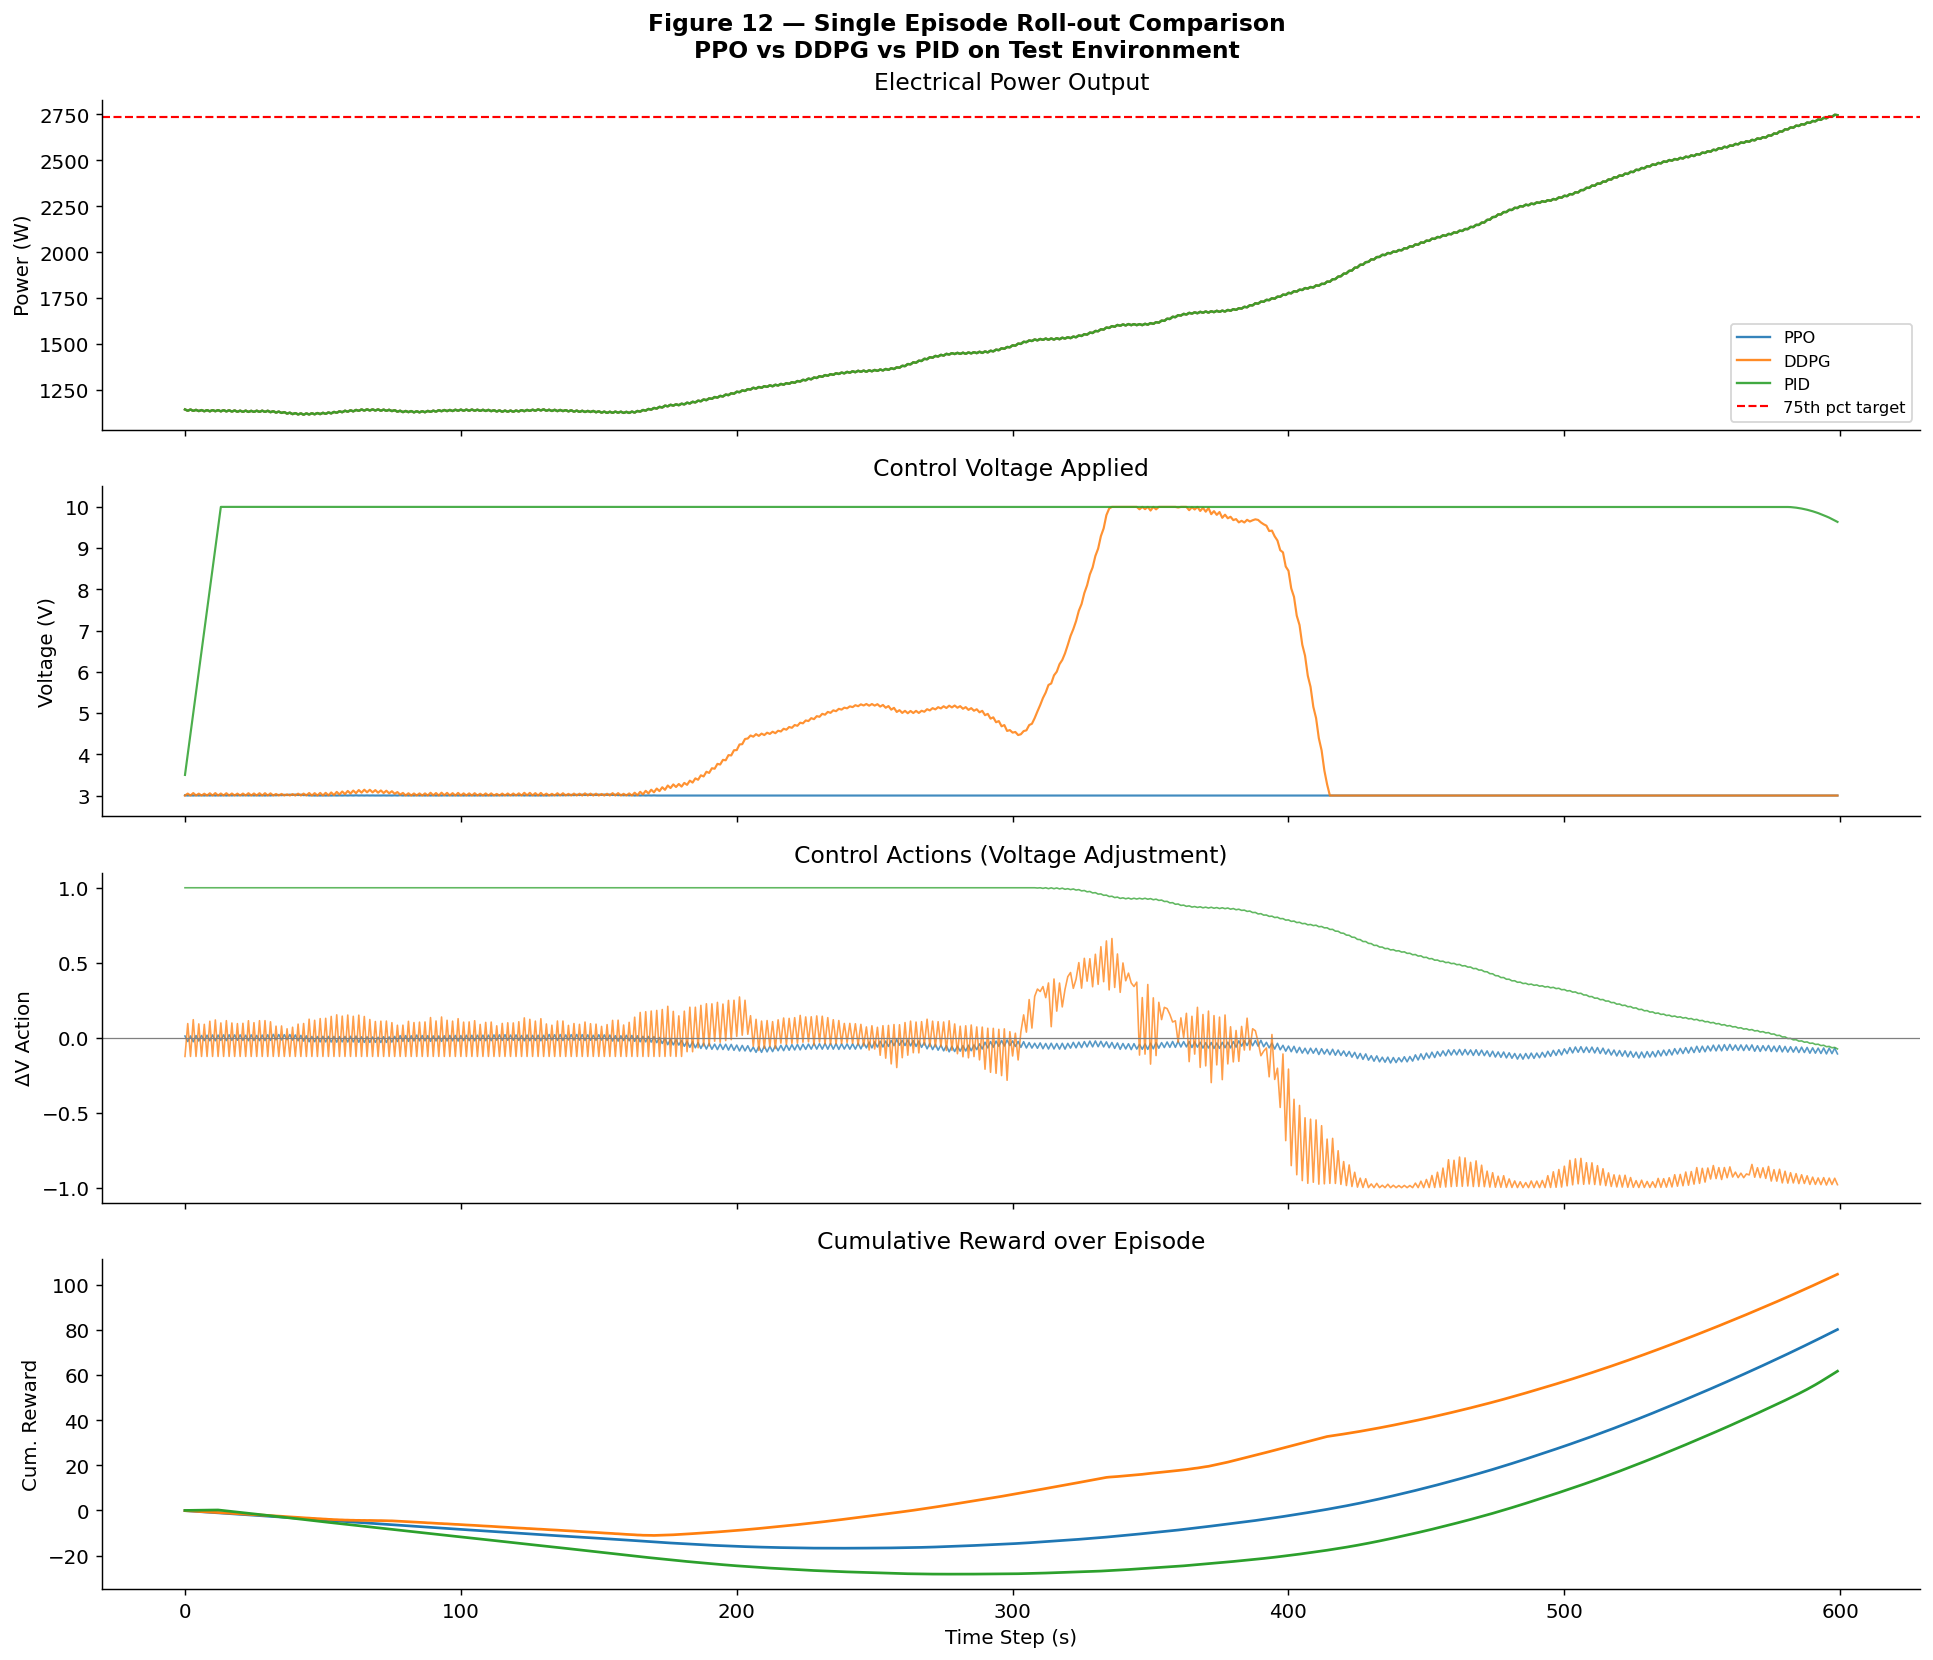

In [70]:
fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)
fig.suptitle('Figure 12 — Single Episode Roll-out Comparison\n'
             'PPO vs DDPG vs PID on Test Environment',
             fontsize=13, fontweight='bold')

rollout_policies = {'PPO': ppo_policy, 'DDPG': ddpg_policy, 'PID': pid_policy}
rollout_colors   = {'PPO': PAL[0], 'DDPG': PAL[1], 'PID': PAL[2]}

for name, fn in rollout_policies.items():
    obs, _ = env_test.reset(seed=42)
    powers, actions, voltages, cum_rewards = [], [], [], []
    cum_r = 0.0; done = False
    while not done:
        action = fn(obs)
        obs, r, done, _, info = env_test.step(action)
        powers.append(info['power_W'])
        actions.append(float(info['action']))
        voltages.append(info['voltage_V'])
        cum_r += r; cum_rewards.append(cum_r)

    t = np.arange(len(powers))
    axes[0].plot(t, powers,      color=rollout_colors[name], lw=1.3, label=name, alpha=0.9)
    axes[1].plot(t, voltages,    color=rollout_colors[name], lw=1.2, alpha=0.85)
    axes[2].plot(t, actions,     color=rollout_colors[name], lw=0.9, alpha=0.75)
    axes[3].plot(t, cum_rewards, color=rollout_colors[name], lw=1.5)

axes[0].axhline(np.percentile(df_test['el_power_smooth'], 75),
                color='red', ls='--', lw=1.2, label='75th pct target')
axes[0].set_ylabel('Power (W)'); axes[0].set_title('Electrical Power Output')
axes[0].legend(loc='lower right', fontsize=9)

axes[1].set_ylabel('Voltage (V)'); axes[1].set_title('Control Voltage Applied')
axes[1].set_ylim(V_MIN - 0.5, V_MAX + 0.5)

axes[2].axhline(0, color='grey', lw=0.7)
axes[2].set_ylabel('ΔV Action'); axes[2].set_title('Control Actions (Voltage Adjustment)')

axes[3].set_ylabel('Cum. Reward'); axes[3].set_xlabel('Time Step (s)')
axes[3].set_title('Cumulative Reward over Episode')

plt.tight_layout()
plt.savefig('figures/fig12_rollout_comparison.png')
plt.show()


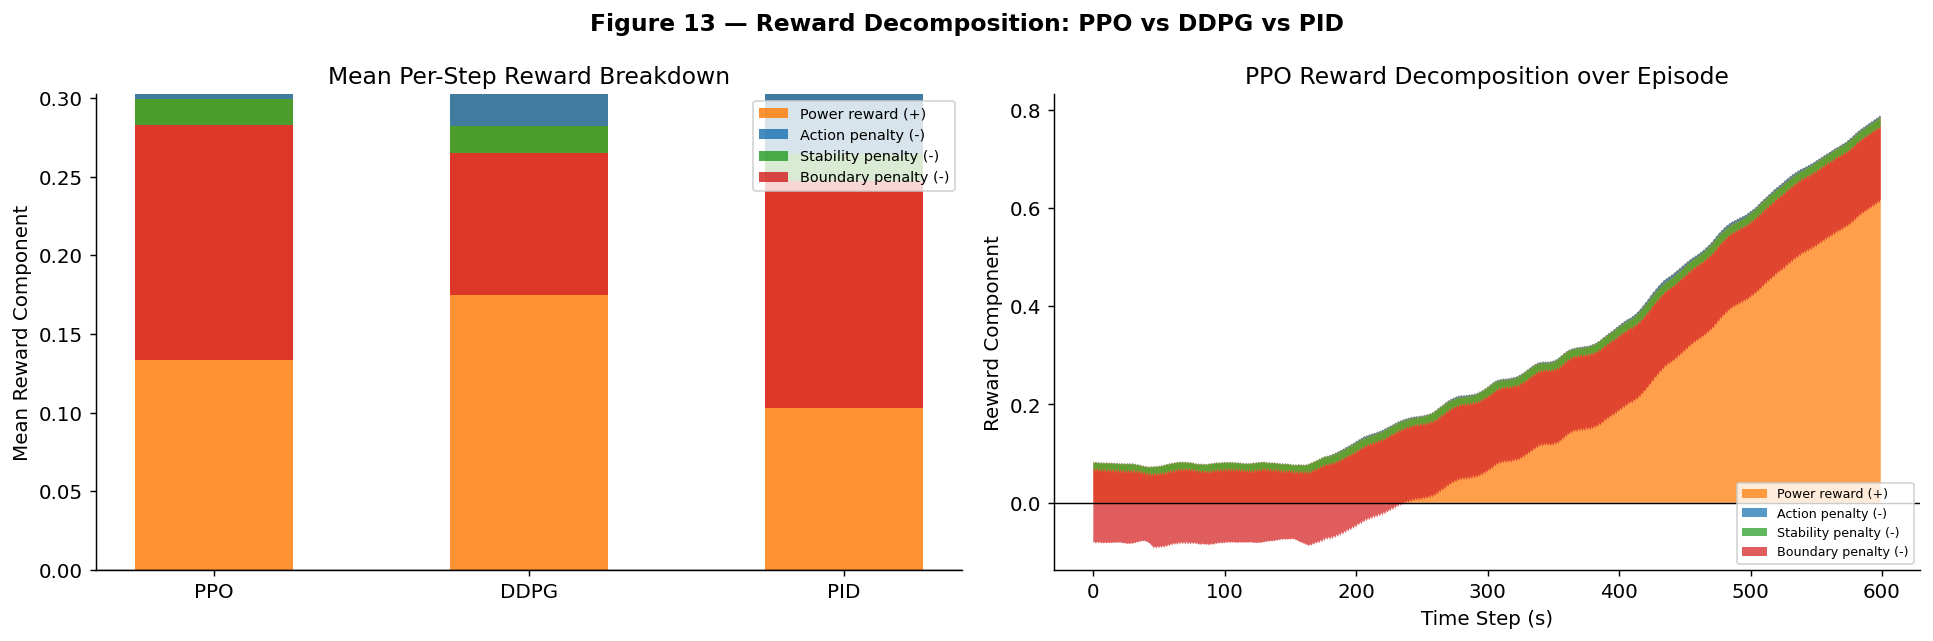


Mean per-step reward decomposition:
  PPO   : power=+0.3024  action=-0.0029  stability=-0.0170  boundary=-0.1487  total=+0.1337
  DDPG  : power=+0.3024  action=-0.0203  stability=-0.0170  boundary=-0.0905  total=+0.1746
  PID   : power=+0.3024  action=-0.0382  stability=-0.0170  boundary=-0.1442  total=+0.1029


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Figure 13 — Reward Decomposition: PPO vs DDPG vs PID',
             fontsize=13, fontweight='bold')

# Collect reward components
comp_data = {}
for name, fn in rollout_policies.items():
    obs, _ = env_test.reset(seed=42)
    rp, ra, rs, rb = [], [], [], []
    done = False
    while not done:
        action = fn(obs)
        obs, r, done, _, info = env_test.step(action)
        rp.append(info['r_power']); ra.append(info['r_action'])
        rs.append(info['r_stability']); rb.append(info['r_boundary'])
    comp_data[name] = {
        'power'   : np.mean(rp),
        'action'  : np.mean(ra),
        'stability':np.mean(rs),
        'boundary': np.mean(rb),
        'total'   : np.mean(rp)+np.mean(ra)+np.mean(rs)+np.mean(rb)
    }

# Stacked bar
x = np.arange(len(rollout_policies))
w = 0.5
comps  = ['power','action','stability','boundary']
clabels= ['Power reward (+)','Action penalty (-)','Stability penalty (-)','Boundary penalty (-)']
ccolors= [PAL[1], PAL[0], PAL[2], PAL[3]]
bottoms= np.zeros(len(rollout_policies))
for comp, clabel, ccol in zip(comps, clabels, ccolors):
    vals = [comp_data[n][comp] for n in rollout_policies]
    axes[0].bar(x, vals, w, bottom=bottoms, label=clabel, color=ccol, alpha=0.85)
    bottoms += np.array(vals)
axes[0].set_xticks(x); axes[0].set_xticklabels(list(rollout_policies.keys()))
axes[0].set_title('Mean Per-Step Reward Breakdown'); axes[0].set_ylabel('Mean Reward Component')
axes[0].axhline(0, color='black', lw=0.8); axes[0].legend(fontsize=8, loc='upper right')

# Time-series stacked area for PPO
obs, _ = env_test.reset(seed=42)
rp, ra, rs, rb = [], [], [], []
done = False
while not done:
    action = ppo_policy(obs); obs, r, done, _, info = env_test.step(action)
    rp.append(info['r_power']); ra.append(info['r_action'])
    rs.append(info['r_stability']); rb.append(info['r_boundary'])
t = np.arange(len(rp))
axes[1].stackplot(t, rp, ra, rs, rb, labels=clabels, colors=ccolors, alpha=0.75)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('PPO Reward Decomposition over Episode')
axes[1].set_xlabel('Time Step (s)'); axes[1].set_ylabel('Reward Component')
axes[1].legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('figures/fig13_reward_decomposition.png')
plt.show()

print('\nMean per-step reward decomposition:')
for name in rollout_policies:
    d = comp_data[name]
    print(f"  {name:6s}: power={d['power']:+.4f}  action={d['action']:+.4f}  "
          f"stability={d['stability']:+.4f}  boundary={d['boundary']:+.4f}  total={d['total']:+.4f}")


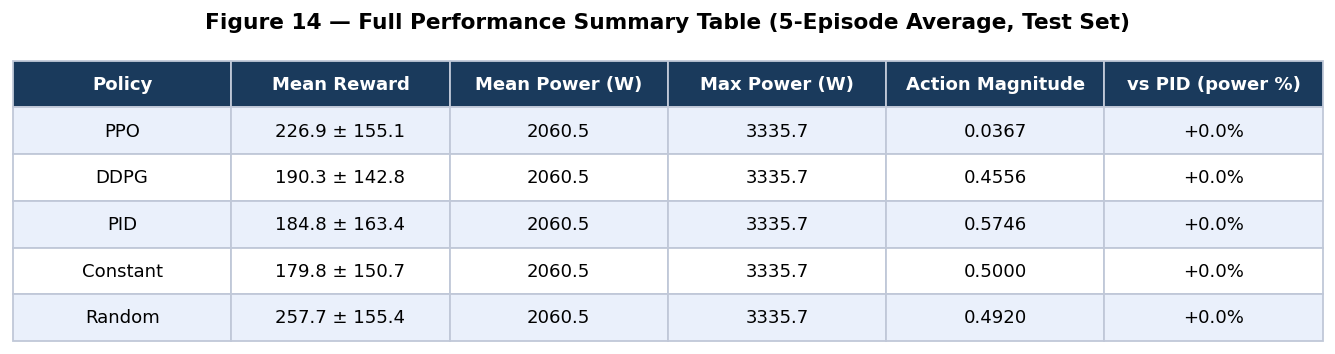


Summary DataFrame:


,Policy,Mean Reward,Mean Power (W),Max Power (W),Action Magnitude,vs PID (power %)
0,PPO,226.9 ± 155.1,2060.5,3335.7,0.0367,+0.0%
1,DDPG,190.3 ± 142.8,2060.5,3335.7,0.4556,+0.0%
2,PID,184.8 ± 163.4,2060.5,3335.7,0.5746,+0.0%
3,Constant,179.8 ± 150.7,2060.5,3335.7,0.5000,+0.0%
4,Random,257.7 ± 155.4,2060.5,3335.7,0.4920,+0.0%


In [74]:
summary_rows = []
for name in results:
    r = results[name]
    all_ep_r = [sum(ep) for ep in r['rewards']]
    all_ep_p = [np.mean(ep) for ep in r['powers_W']]
    all_ep_a = [np.mean(np.abs(ep)) for ep in r['actions']]
    summary_rows.append({
        'Policy'           : name,
        'Mean Reward'      : f"{np.mean(all_ep_r):.1f} ± {np.std(all_ep_r):.1f}",
        'Mean Power (W)'   : f"{np.mean(all_ep_p):.1f}",
        'Max Power (W)'    : f"{max([max(ep) for ep in r['powers_W']]):.1f}",
        'Action Magnitude' : f"{np.mean(all_ep_a):.4f}",
        'vs PID (power %)' : f"{(np.mean(all_ep_p)-results['PID']['mean_power_W'])/results['PID']['mean_power_W']*100:+.1f}%"
    })
summary_df = pd.DataFrame(summary_rows)

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.axis('off')
tbl = ax.table(
    cellText  = summary_df.values,
    colLabels = summary_df.columns,
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0, 1, 1]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a3a5c'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 1: cell.set_facecolor('#eaf0fb')
    else:            cell.set_facecolor('#ffffff')
    cell.set_edgecolor('#c0c8d8')

ax.set_title('Figure 14 — Full Performance Summary Table (5-Episode Average, Test Set)',
             fontsize=12, fontweight='bold', pad=18)
plt.savefig('figures/fig14_summary_table.png')
plt.show()
print('\nSummary DataFrame:')
display(summary_df)

In [76]:
print('All figures saved to: figures/')
print('All models saved to:  models/')
print()
for f in sorted(os.listdir('figures')):
    print(f'  figures/{f}')

All figures saved to: figures/
All models saved to:  models/

  figures/fig01_raw_time_series.png
  figures/fig02_experiment_statistics.png
  figures/fig03_voltage_power_analysis.png
  figures/fig04_cross_correlation.png
  figures/fig05_distributions.png
  figures/fig06_smoothing_features.png
  figures/fig07_correlation_heatmap.png
  figures/fig08_scaling.png
  figures/fig09_environment_design.png
  figures/fig10_training_curves.png
  figures/fig11_policy_comparison.png
  figures/fig12_rollout_comparison.png
  figures/fig13_reward_decomposition.png
  figures/fig14_summary_table.png
